In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
import pandas as pd
import numpy as np
import glob 
import duckdb
import os
os.chdir("..")
import plotting_helpers
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from trebl_tools import plotting

# Calculating activity per BC combo

In [3]:
# Loading in step 1 map

con = duckdb.connect("../../duckdb/GCN4_activity_scores.db")

con.execute("""
CREATE TABLE step1_map AS
SELECT DISTINCT
    AD,
    AD_BC,
    RPTR_BC
FROM read_csv_auto('../../output/GCN4_pipeline/step1.csv');
SELECT * FROM step1_map LIMIT 5;
""").fetchdf()

# Getting all AD counts

In [4]:
# Reading in simple AD counts

con.execute("""
CREATE TABLE AD_simple AS
SELECT
    AD,
    AD_BC,
    count,
    AD || AD_BC AS gene,
    regexp_extract(filename, 'AD_(\\d+)_', 1)::INT AS rep,
    regexp_extract(filename, 'AD_\\d+_(\\d+)', 1)::INT AS time
FROM read_csv_auto(
    '../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*AD*/*simple*',
    delim='\t',
    filename=true
);
SELECT * FROM AD_simple LIMIT 5;
""").fetchdf()

CatalogException: Catalog Error: Table with name "AD_simple" already exists!

In [ ]:
# Reading in directional AD counts

con.execute("""
CREATE TABLE AD_directional AS
SELECT
    gene,
    count,
    regexp_extract(filename, 'AD_(\\d+)_', 1)::INT AS rep,
    regexp_extract(filename, 'AD_\\d+_(\\d+)', 1)::INT AS time
FROM read_csv_auto(
    '../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*AD*/*directional*',
    delim='\t',
    filename=true
);
SELECT * FROM AD_directional LIMIT 5;
""").fetchdf()

In [ ]:
# Merge both AD tables together

con.execute("""
CREATE TABLE AD_merged AS
SELECT
    s.gene,
    s.AD,
    s.AD_BC,
    s.rep,
    s.time,
    s.count AS count_simple,
    d.count AS count_directional
FROM AD_simple s
JOIN AD_directional d
USING (gene, rep, time);
SELECT * FROM AD_merged LIMIT 5;
""").fetchdf()

In [5]:
AD_merged_counts_only = con.execute("SELECT count_simple, count_directional FROM AD_merged").fetchdf()
AD_merged_counts_only["count_diff"] = AD_merged_counts_only["count_simple"] - AD_merged_counts_only["count_directional"]
AD_merged_counts_only

,count_simple,count_directional,count_diff
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
...,...,...,...
58612312,1,1,0
58612313,1,1,0
58612314,1,1,0
58612315,1,1,0


Text(0, 0.5, 'Complex UMI Count')

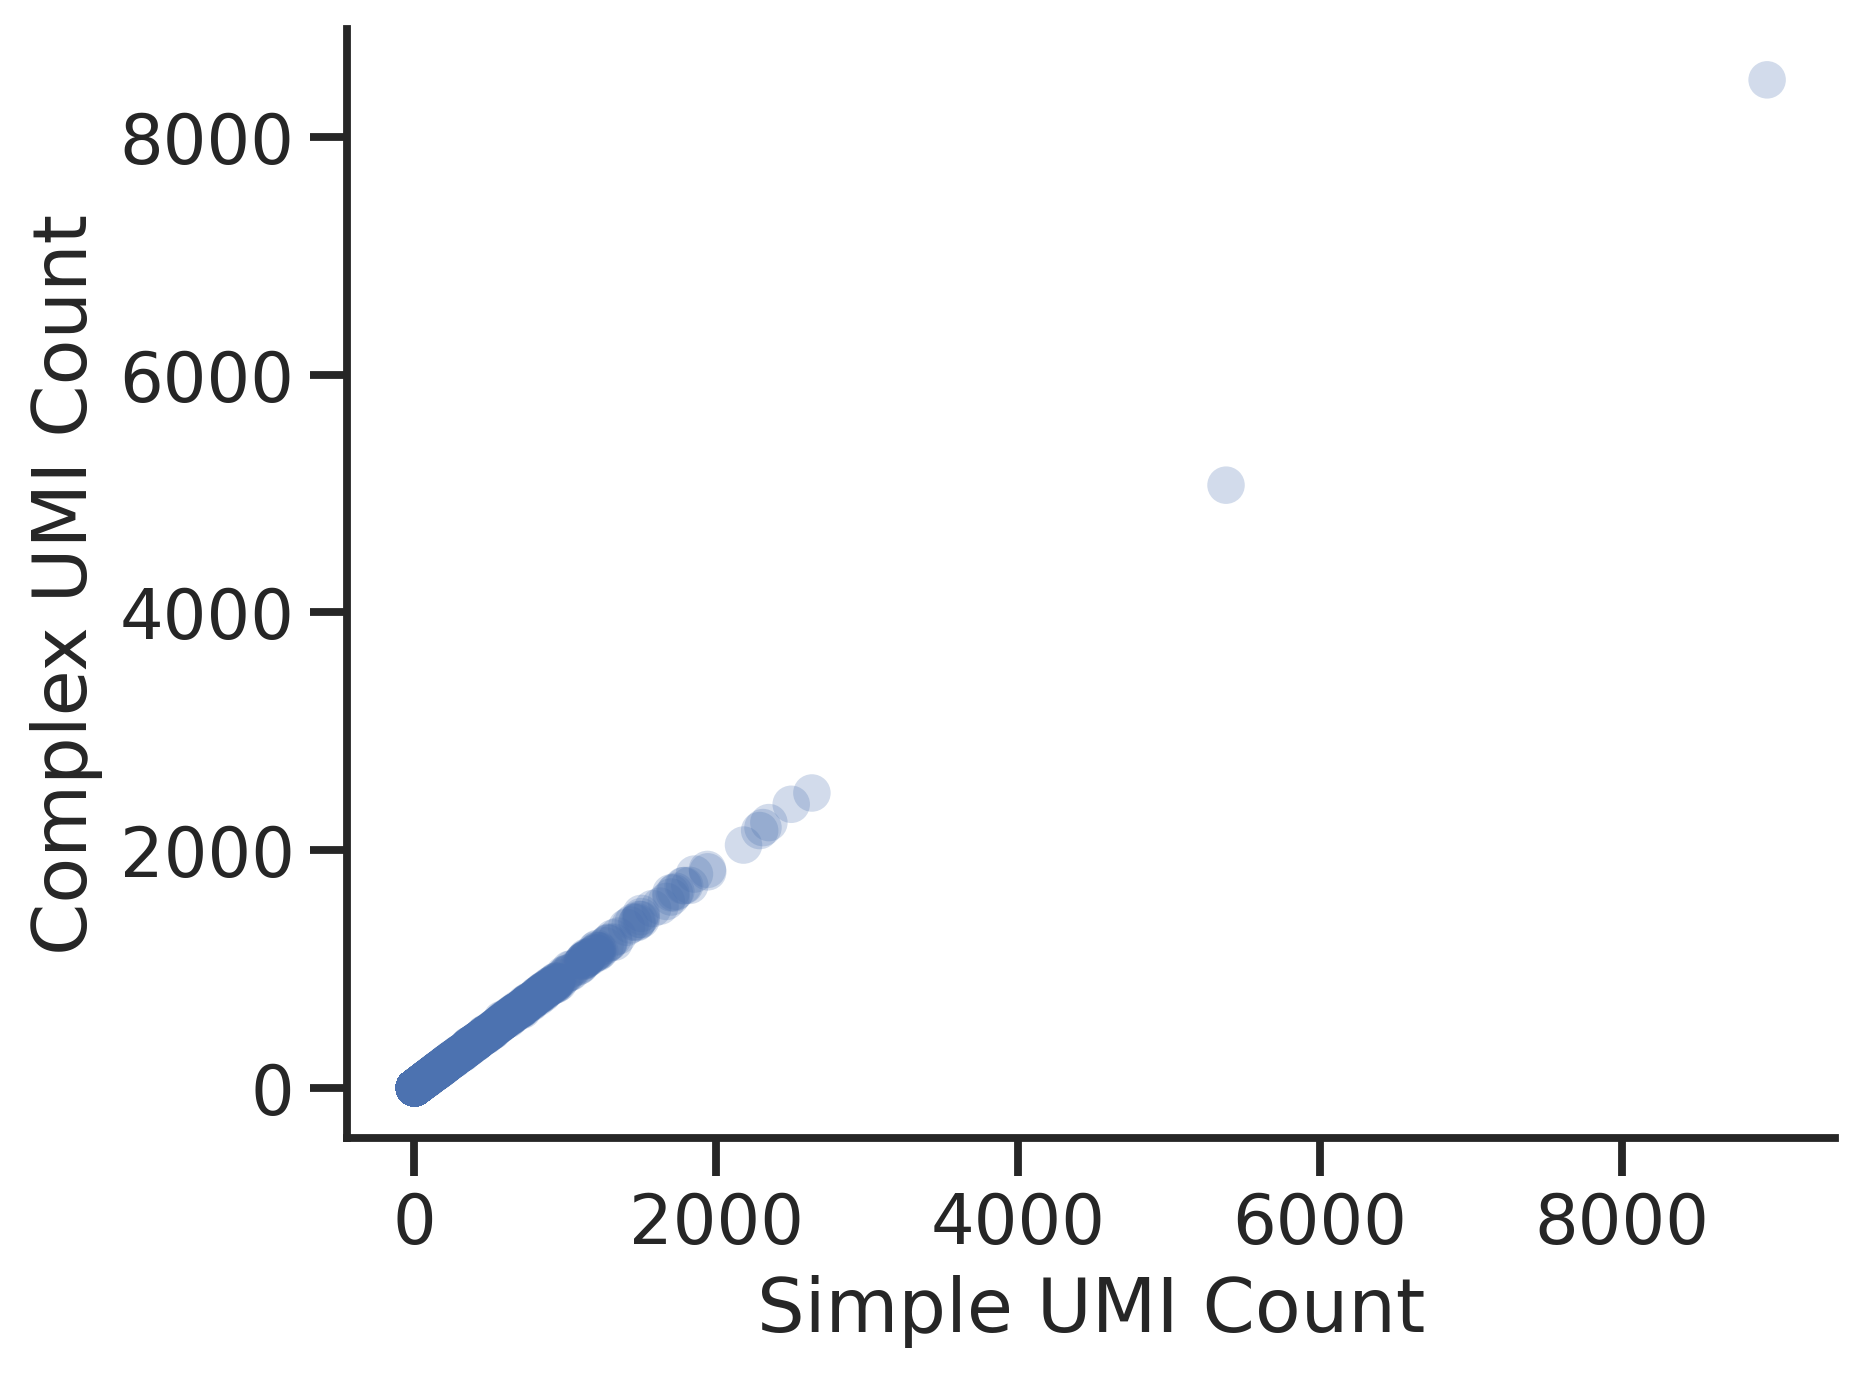

In [6]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.scatterplot(data = AD_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_directional", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Complex UMI Count")

Text(0, 0.5, 'Difference from\nComplex UMI Count')

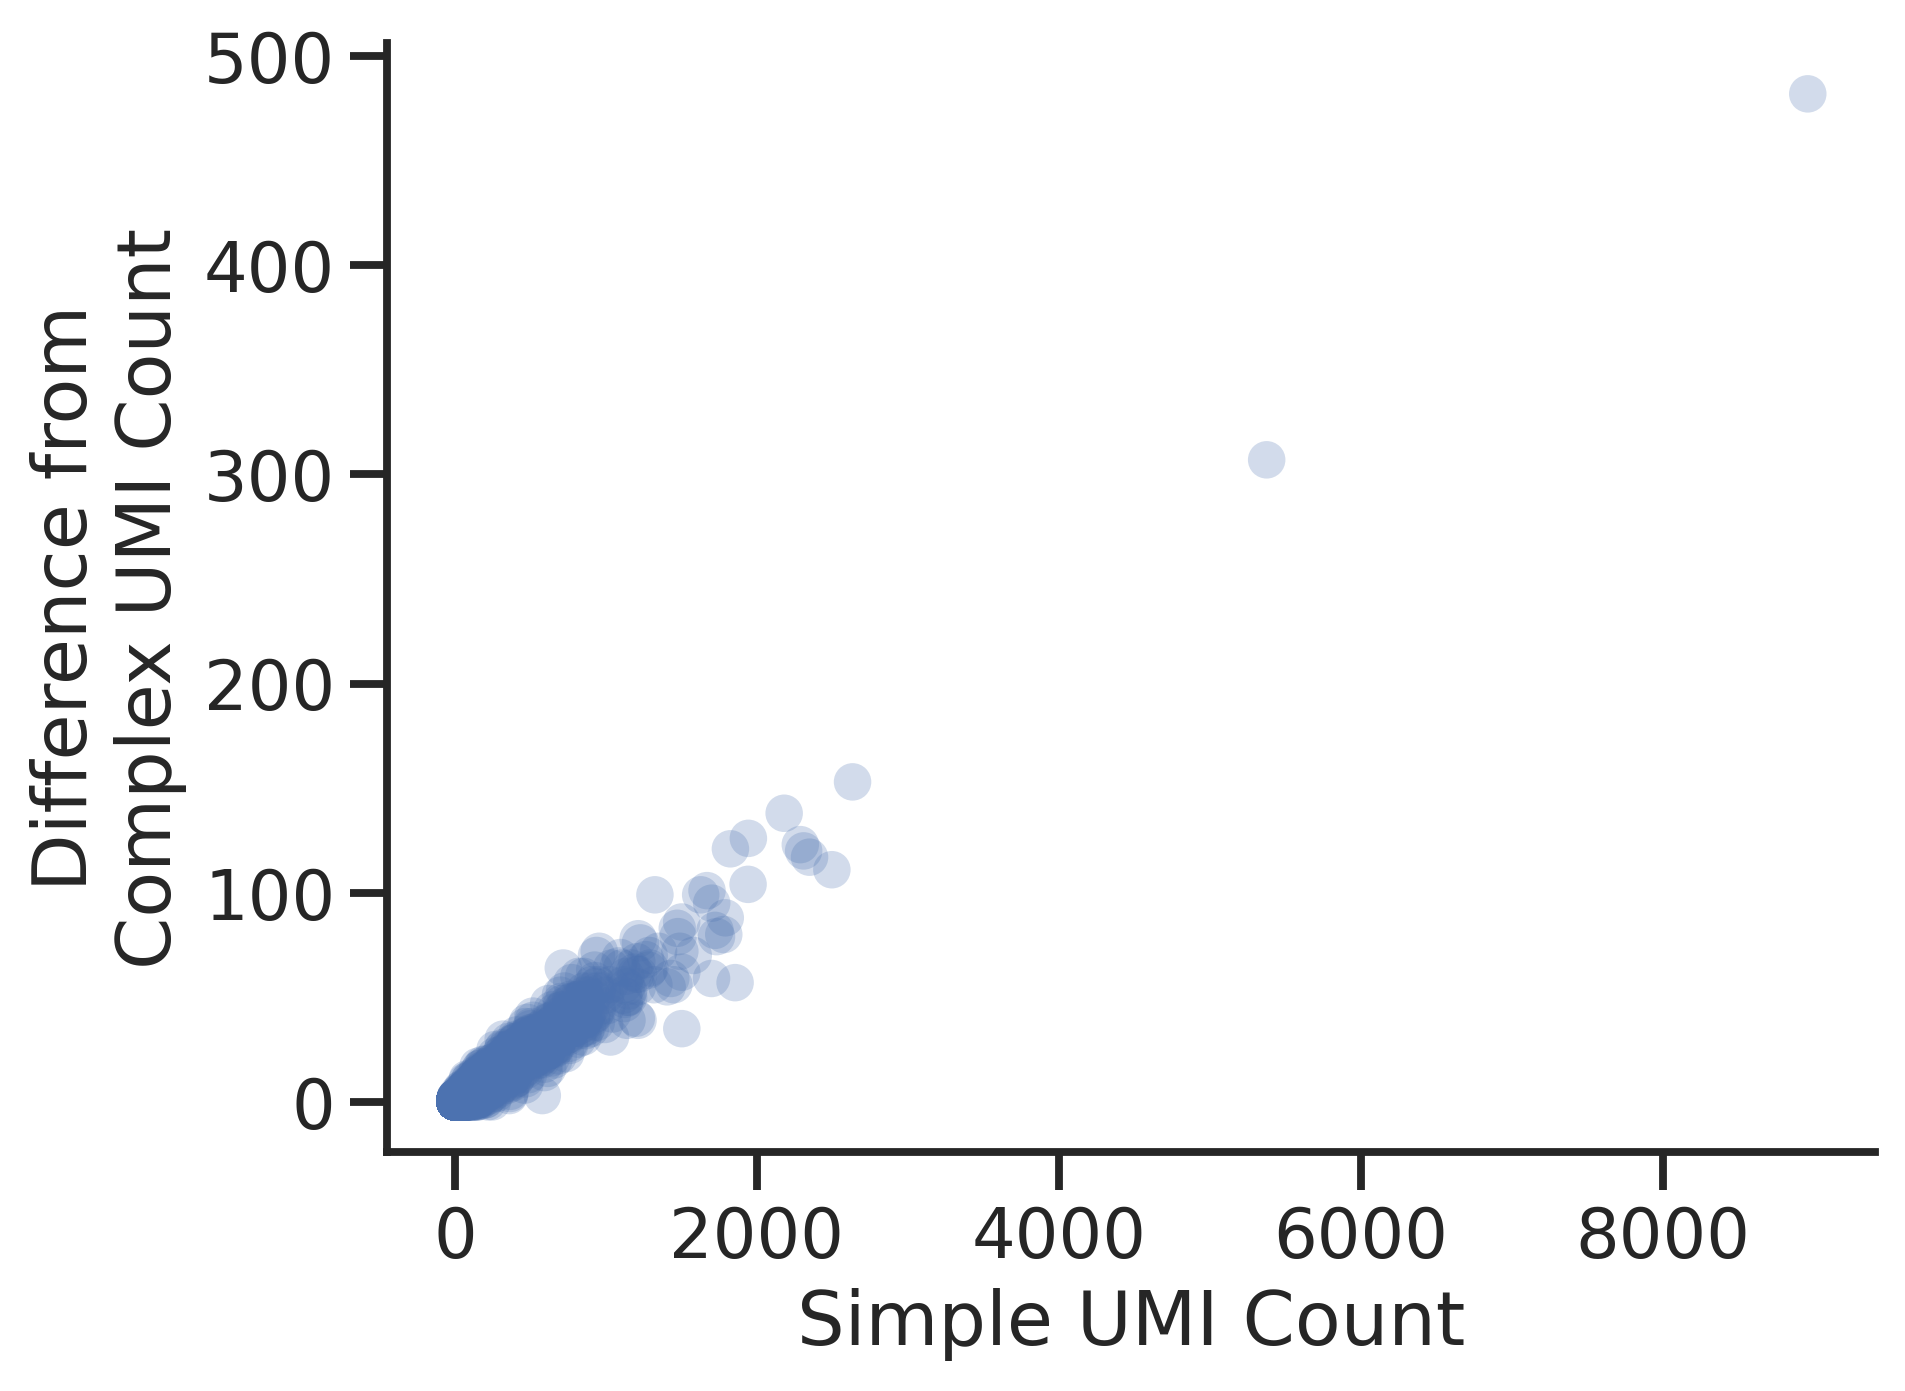

In [7]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)

sns.scatterplot(data = AD_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_diff", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Difference from\nComplex UMI Count")

# Get all RT Counts

In [ ]:
# Reading in RT simple counts
con.execute("""
CREATE OR REPLACE TABLE RT_simple AS
SELECT
    RPTR_BC,
    count,
    regexp_extract(filename,'RPTR_(\\d+)_',1)::INT AS rep,
    regexp_extract(filename,'RPTR_\\d+_(\\d+)',1)::INT AS time,
    RPTR_BC AS gene
FROM read_csv_auto(
'../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*RPTR*/*simple*',
delim='\t',
filename=true
);
SELECT * FROM RT_simple LIMIT 5;
""").fetchdf()

In [ ]:
# Reading in RT directional counts
con.execute("""
CREATE TABLE RT_directional AS
SELECT
    gene,
    count,
    regexp_extract(filename,'RPTR_(\\d+)_',1)::INT AS rep,
    regexp_extract(filename,'RPTR_\\d+_(\\d+)',1)::INT AS time
FROM read_csv_auto(
'../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*RPTR*/*directional*',
delim='\t',
filename=true
);
SELECT * FROM RT_directional LIMIT 5;
""").fetchdf()

In [ ]:
# merge RT results
con.execute("""
CREATE TABLE merged_RT AS
SELECT
    s.RPTR_BC,
    s.rep,
    s.time,
    s.count AS count_simple,
    d.count AS count_directional,
    s.gene
FROM RT_simple s
JOIN RT_directional d
USING (gene, rep, time);
SELECT * FROM merged_RT LIMIT 5;
""").fetchdf()

In [8]:
RT_merged_counts_only = con.execute("SELECT count_simple, count_directional FROM merged_RT").fetchdf()
RT_merged_counts_only["count_diff"] = RT_merged_counts_only["count_simple"] - RT_merged_counts_only["count_directional"]
RT_merged_counts_only

,count_simple,count_directional,count_diff
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
...,...,...,...
50285139,1,1,0
50285140,1,1,0
50285141,1,1,0
50285142,1,1,0


Text(0, 0.5, 'Complex UMI Count')

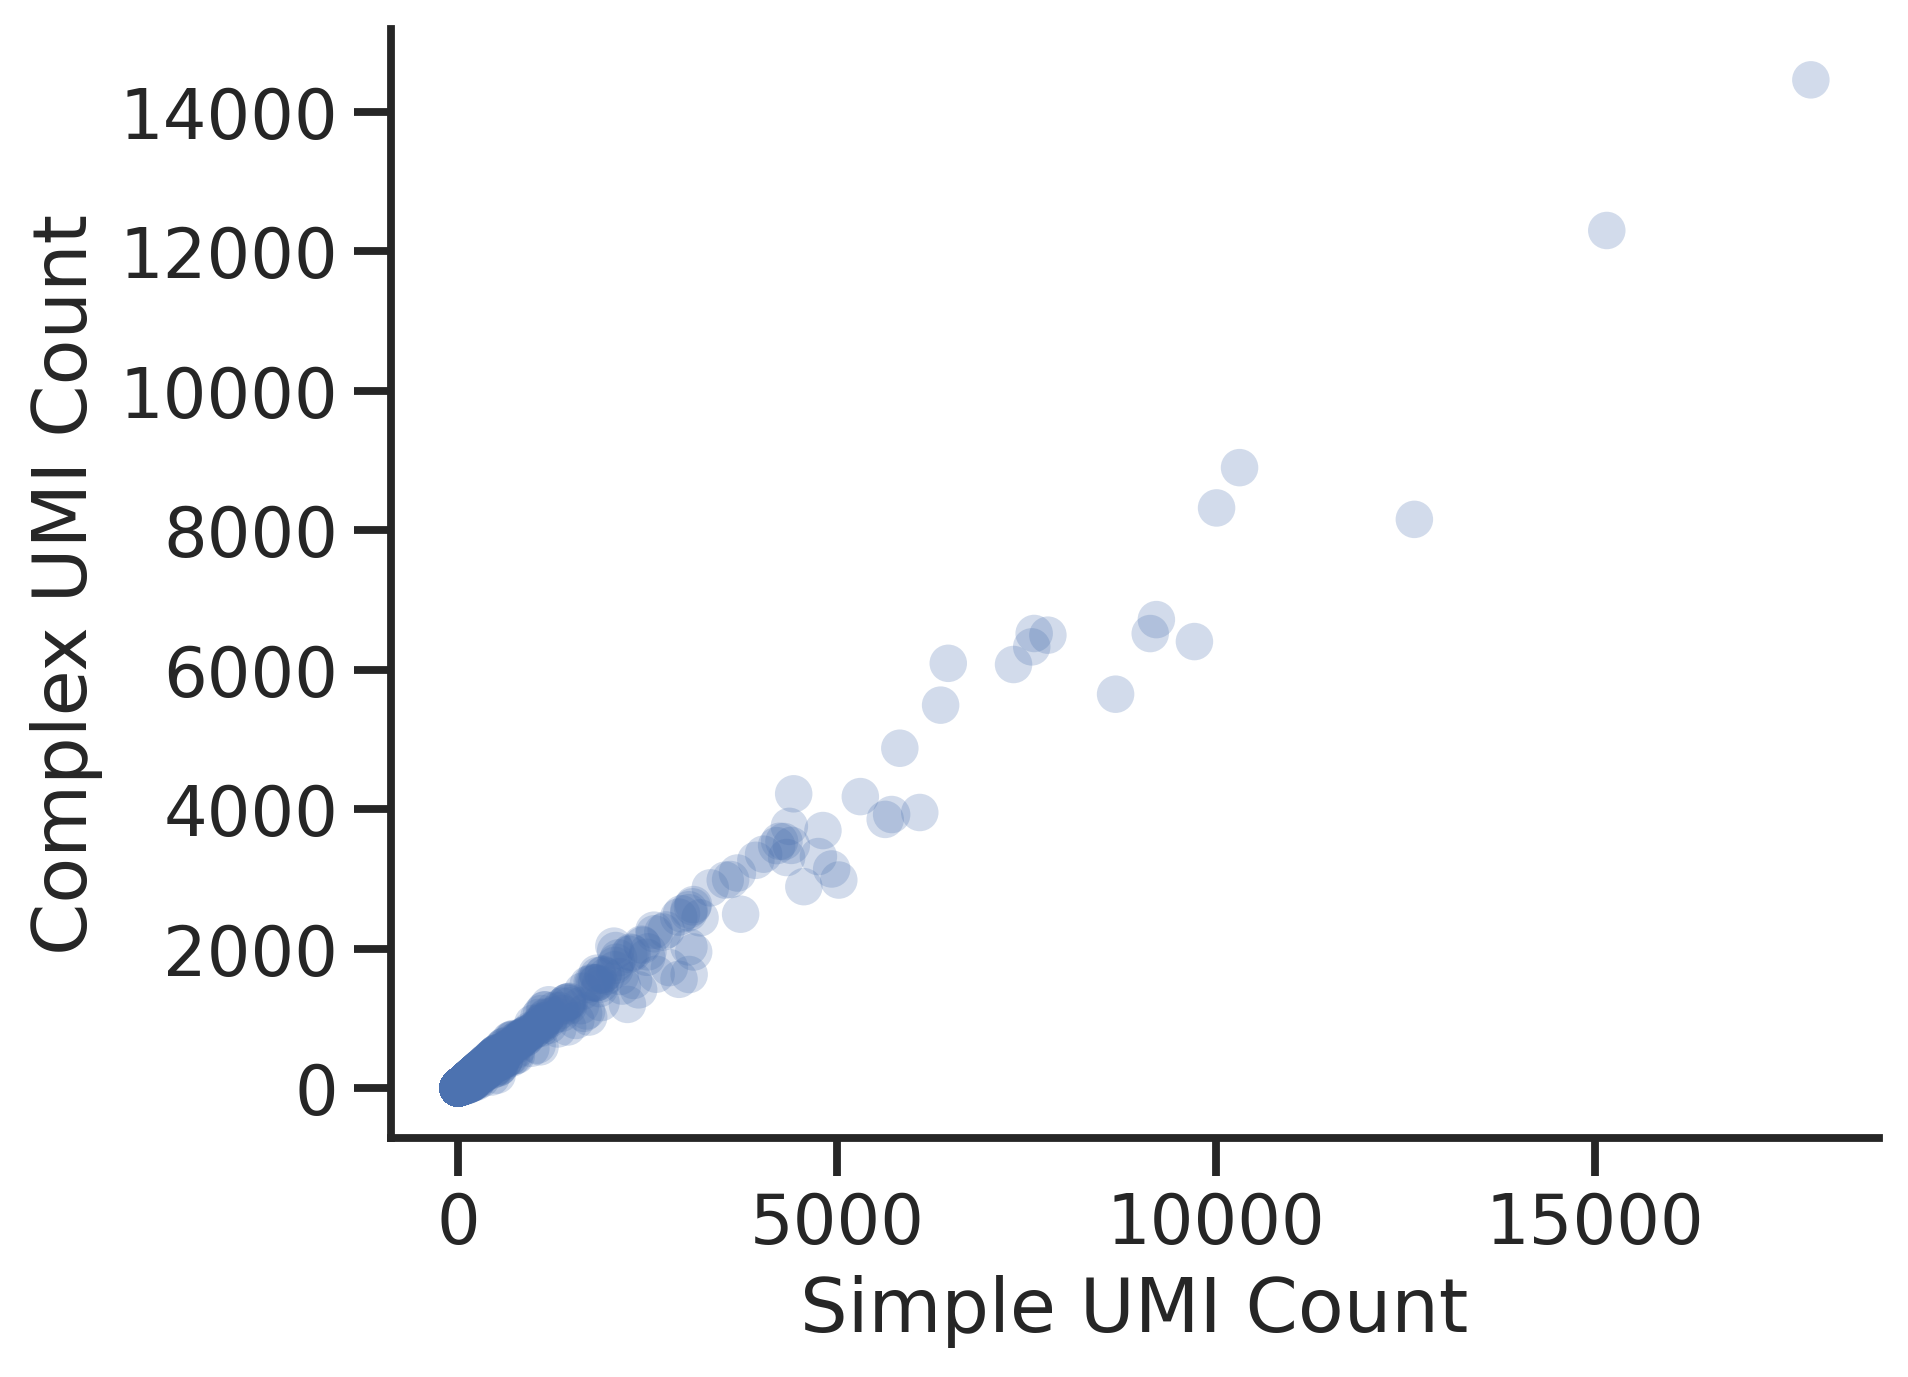

In [9]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.scatterplot(data = RT_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_directional", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Complex UMI Count")

Text(0, 0.5, 'Difference from\nComplex UMI Count')

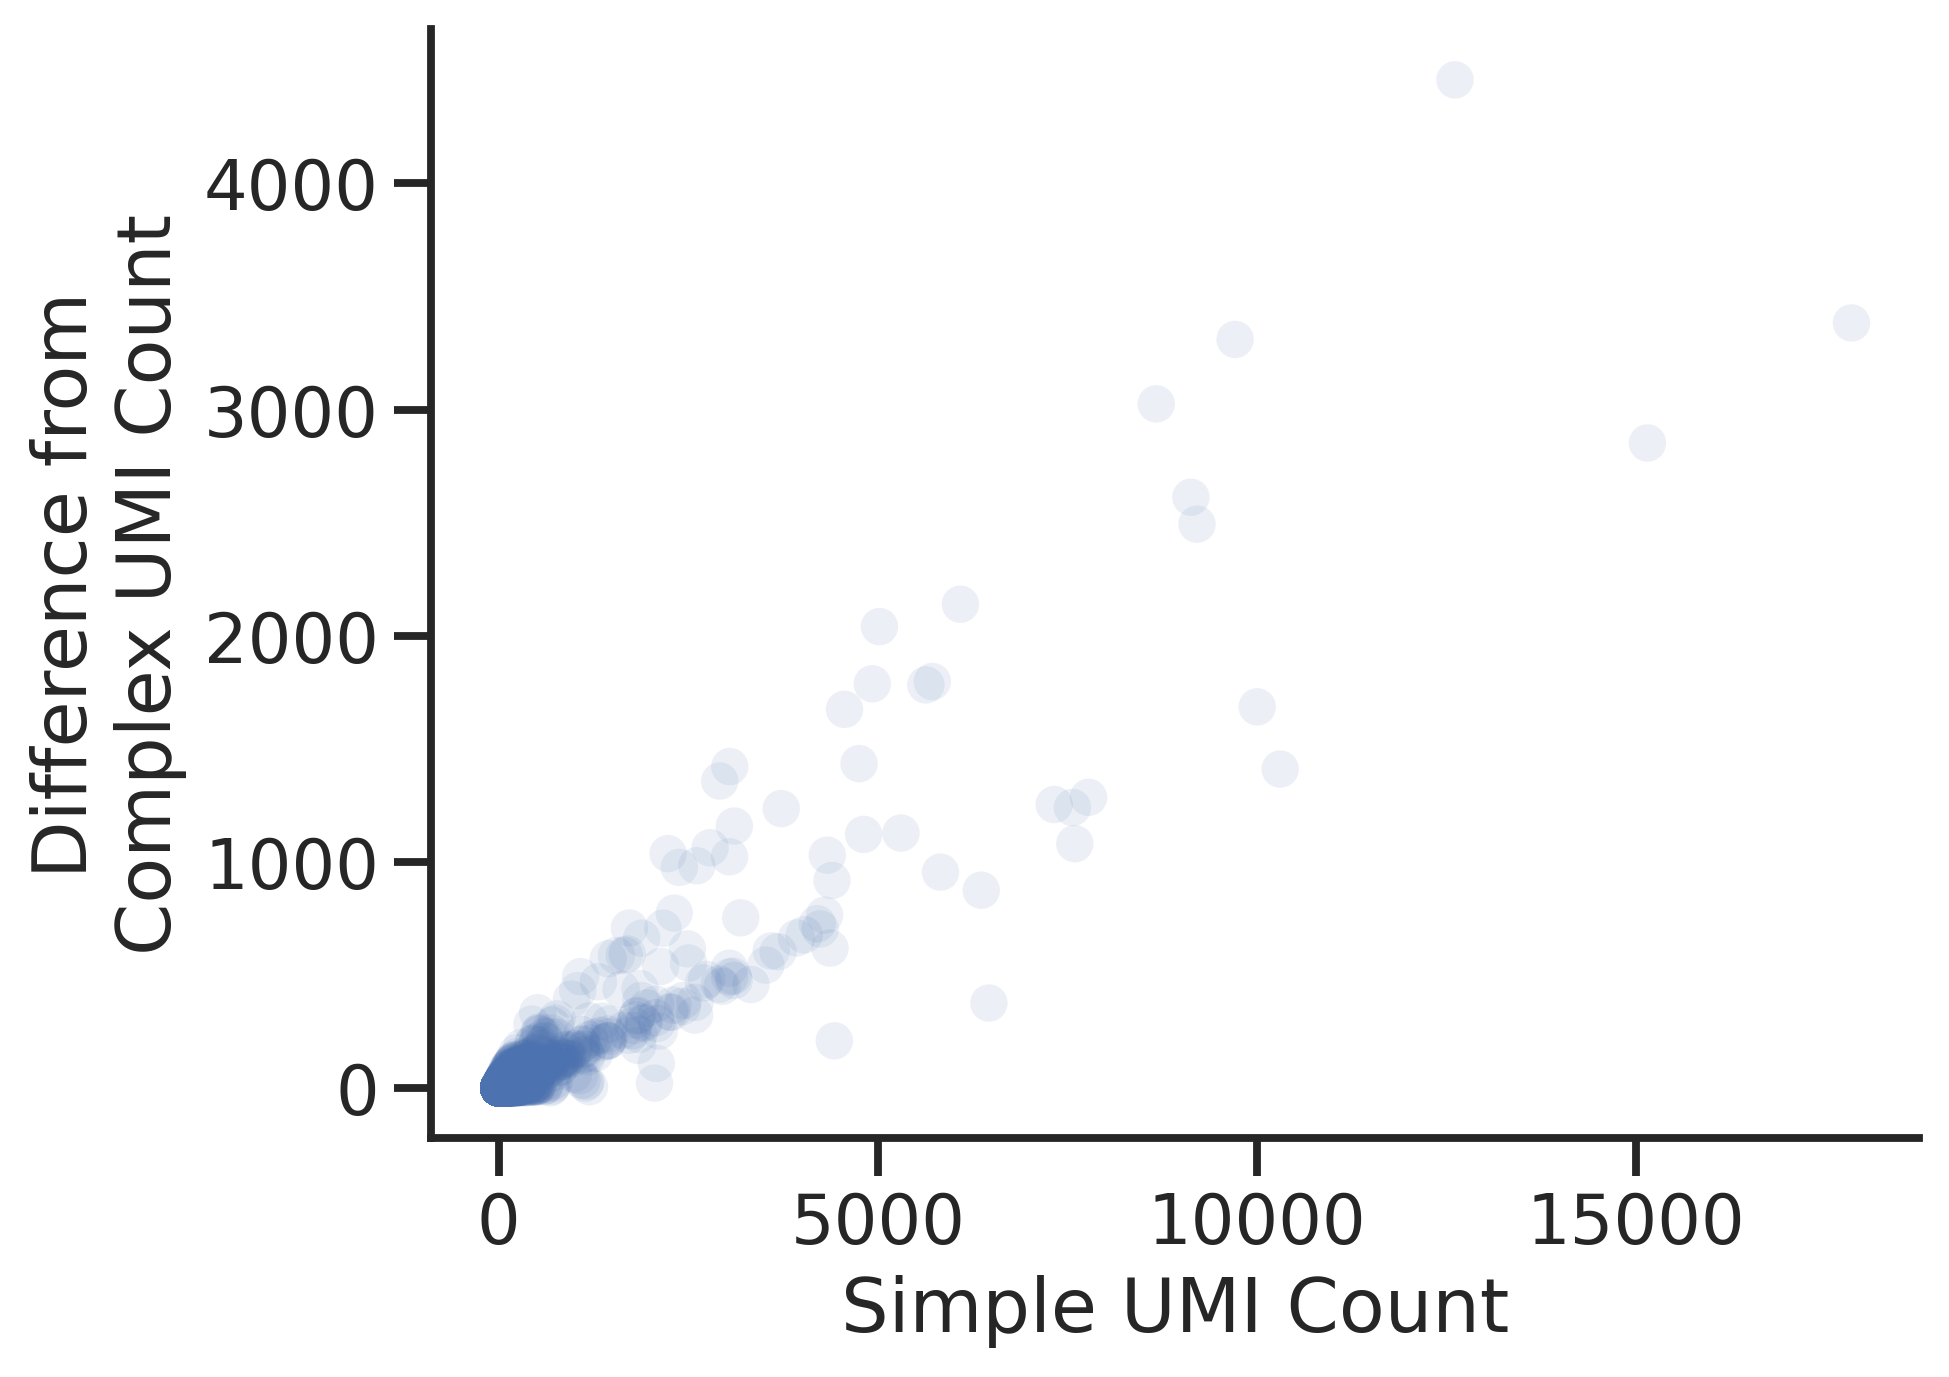

In [10]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)

sns.scatterplot(data = RT_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_diff", 
                edgecolor = 'none',
               alpha = 0.1)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Difference from\nComplex UMI Count")

# Merging with step 1

In [ ]:
# Merge AD results with step 1
con.execute("""
CREATE TABLE step1_map_AD AS
SELECT
    s.*,
    a.count_simple,
    a.count_directional,
    a.rep,
    a.time
FROM step1_map s
JOIN AD_merged a
ON s.AD = a.AD
AND s.AD_BC = a.AD_BC;
SELECT * FROM step1_map_AD LIMIT 5;
""").fetchdf()

In [ ]:
# Merge RT results with step 1
con.execute("""
CREATE TABLE step1_map_RT AS
SELECT
    s.*,
    r.count_simple,
    r.count_directional,
    r.rep,
    r.time
FROM step1_map s
JOIN merged_RT r
ON s.RPTR_BC = r.RPTR_BC;
SELECT * FROM step1_map_AD LIMIT 5;
""").fetchdf()

In [ ]:
con.execute("""
CREATE TABLE AD_RT_merged AS
SELECT
    a.AD,
    a.AD_BC,
    a.RPTR_BC,
    a.rep,
    a.time,

    a.count_simple AS count_simple_AD,
    a.count_directional AS count_directional_AD,

    r.count_simple AS count_simple_RT,
    r.count_directional AS count_directional_RT

FROM step1_map_AD a
JOIN step1_map_RT r
USING (AD, AD_BC, RPTR_BC, rep, time);

SELECT * FROM AD_RT_merged LIMIT 5;
""").fetchdf()

In [ ]:
# Calculate activity
con.execute("""
CREATE TABLE activity AS
SELECT *,
    count_simple_RT / count_simple_AD AS activity_simple,
    count_directional_RT / count_directional_AD AS activity_directional
FROM AD_RT_merged
WHERE
count_simple_AD IS NOT NULL
AND count_simple_RT IS NOT NULL;

SELECT * FROM activity LIMIT 5;

""").fetchdf()

In [38]:
AD_RT_merged = con.execute("SELECT * FROM activity").df()
AD_RT_merged["activity_simple"] = np.log(AD_RT_merged["activity_simple"])
AD_RT_merged["activity_directional"] = np.log(AD_RT_merged["activity_directional"])
AD_RT_merged.to_csv("../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_results_per_barcode.csv")

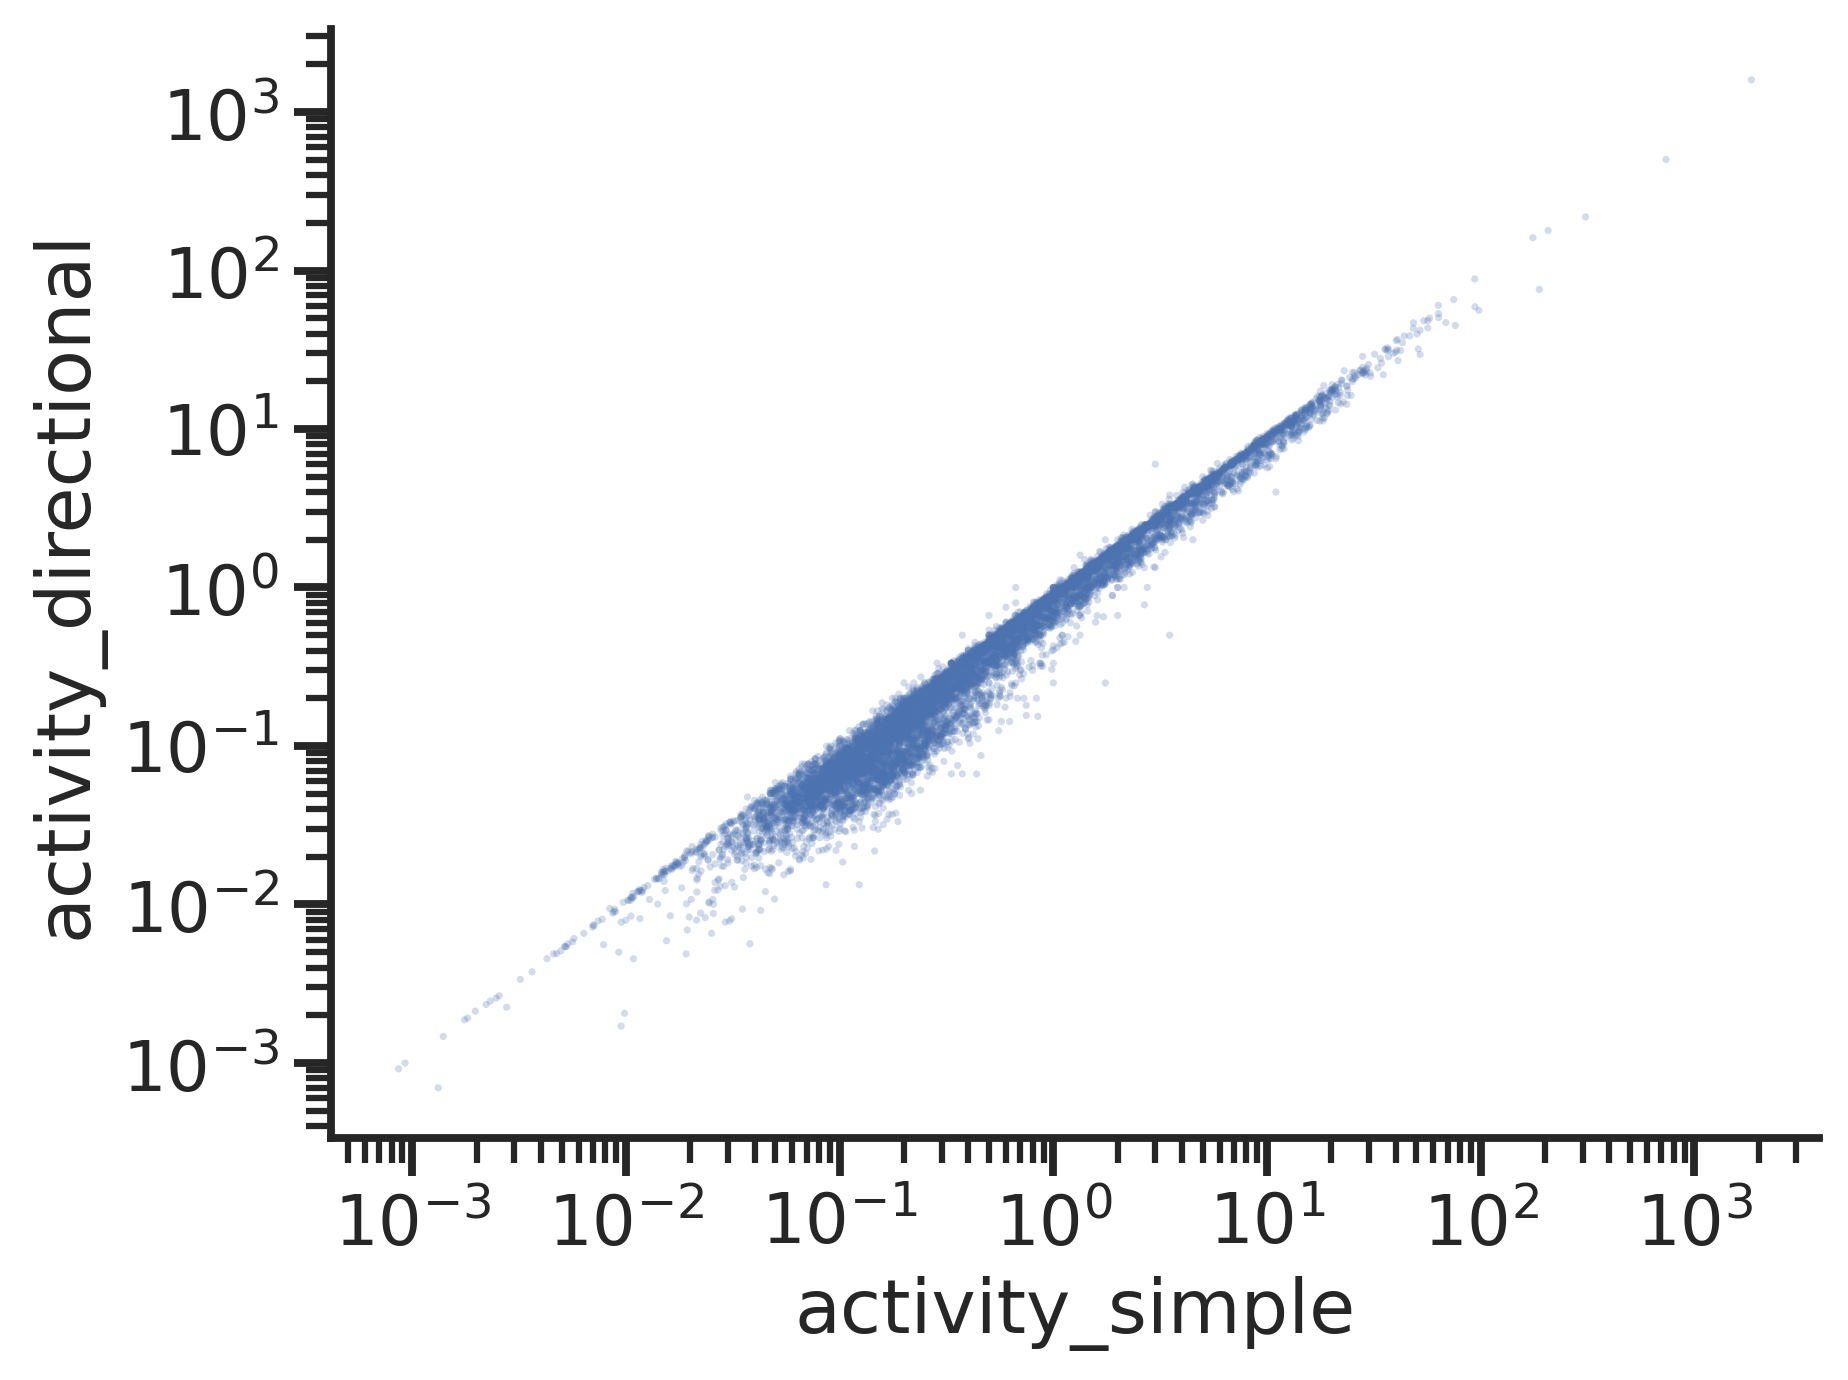

In [12]:
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)

sns.scatterplot(
    data=AD_RT_merged.sample(10000, random_state=44),
    x="activity_simple",
    y="activity_directional",
    edgecolor='none',
    alpha=0.25,
    s=3
)

plt.xscale("log")
plt.yscale("log")

sns.despine()

# Comparing with Emily's data

In [22]:
activity_comparison = pd.read_csv("../../output/GCN4_sk_vs_ec_activities.csv")
activity_comparison

,Unnamed: 0,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
0,0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,3,5,646,402,0.622291,1,403,403.000000
1,1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,3,5,806,2784,3.454094,806,2779,3.447891
2,2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,3,5,657,1349,2.053272,660,1362,2.063636
3,3,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,3,5,917,690,0.752454,920,679,0.738043
4,4,CAAAGACCAACTAGACCACAAGTTCCATTGTTCTCTCAATCTACTG...,GCCCTTGTATT,TTAGTATTTTATCT,3,5,533,140,0.262664,534,139,0.260300
...,...,...,...,...,...,...,...,...,...,...,...,...
296868,296868,ACTTCTGCTTCTTCTGCTTCTCAAATTGTTGTTCATCCAGGTGGTG...,GCCCCCCGTTG,TATGTAATTAACCT,1,240,9,12,1.333333,9,12,1.333333
296869,296869,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,1,240,57,13,0.228070,56,13,0.232143
296870,296870,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,1,240,53,3,0.056604,53,3,0.056604
296871,296871,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,1,240,536,1,0.001866,536,670,1.250000


In [23]:
merged_activities = pd.merge(activity_comparison[["AD", "AD_BC", "RPTR_BC", "EC_AD_umi_count", "EC_RT_umi_count", "rep", "time", "EC_activity"]], 
                             AD_RT_merged[["AD", "AD_BC","count_directional_AD", "count_directional_RT", "RPTR_BC", "rep", "time", "activity_directional"]])
merged_activities

,AD,AD_BC,RPTR_BC,EC_AD_umi_count,EC_RT_umi_count,rep,time,EC_activity,count_directional_AD,count_directional_RT,activity_directional
0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,646,402,3,5,0.622291,617,233,0.377634
1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,806,2784,3,5,3.454094,777,1716,2.208494
2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,657,1349,3,5,2.053272,630,776,1.231746
3,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,917,690,3,5,0.752454,871,405,0.464983
4,CAAAGACCAACTAGACCACAAGTTCCATTGTTCTCTCAATCTACTG...,GCCCTTGTATT,TTAGTATTTTATCT,533,140,3,5,0.262664,508,86,0.169291
...,...,...,...,...,...,...,...,...,...,...,...
296539,ACTTCTGCTTCTTCTGCTTCTCAAATTGTTGTTCATCCAGGTGGTG...,GCCCCCCGTTG,TATGTAATTAACCT,9,12,1,240,1.333333,8,11,1.375000
296540,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,57,13,1,240,0.228070,55,10,0.181818
296541,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,53,3,1,240,0.056604,51,3,0.058824
296542,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,536,1,1,240,0.001866,514,557,1.083658


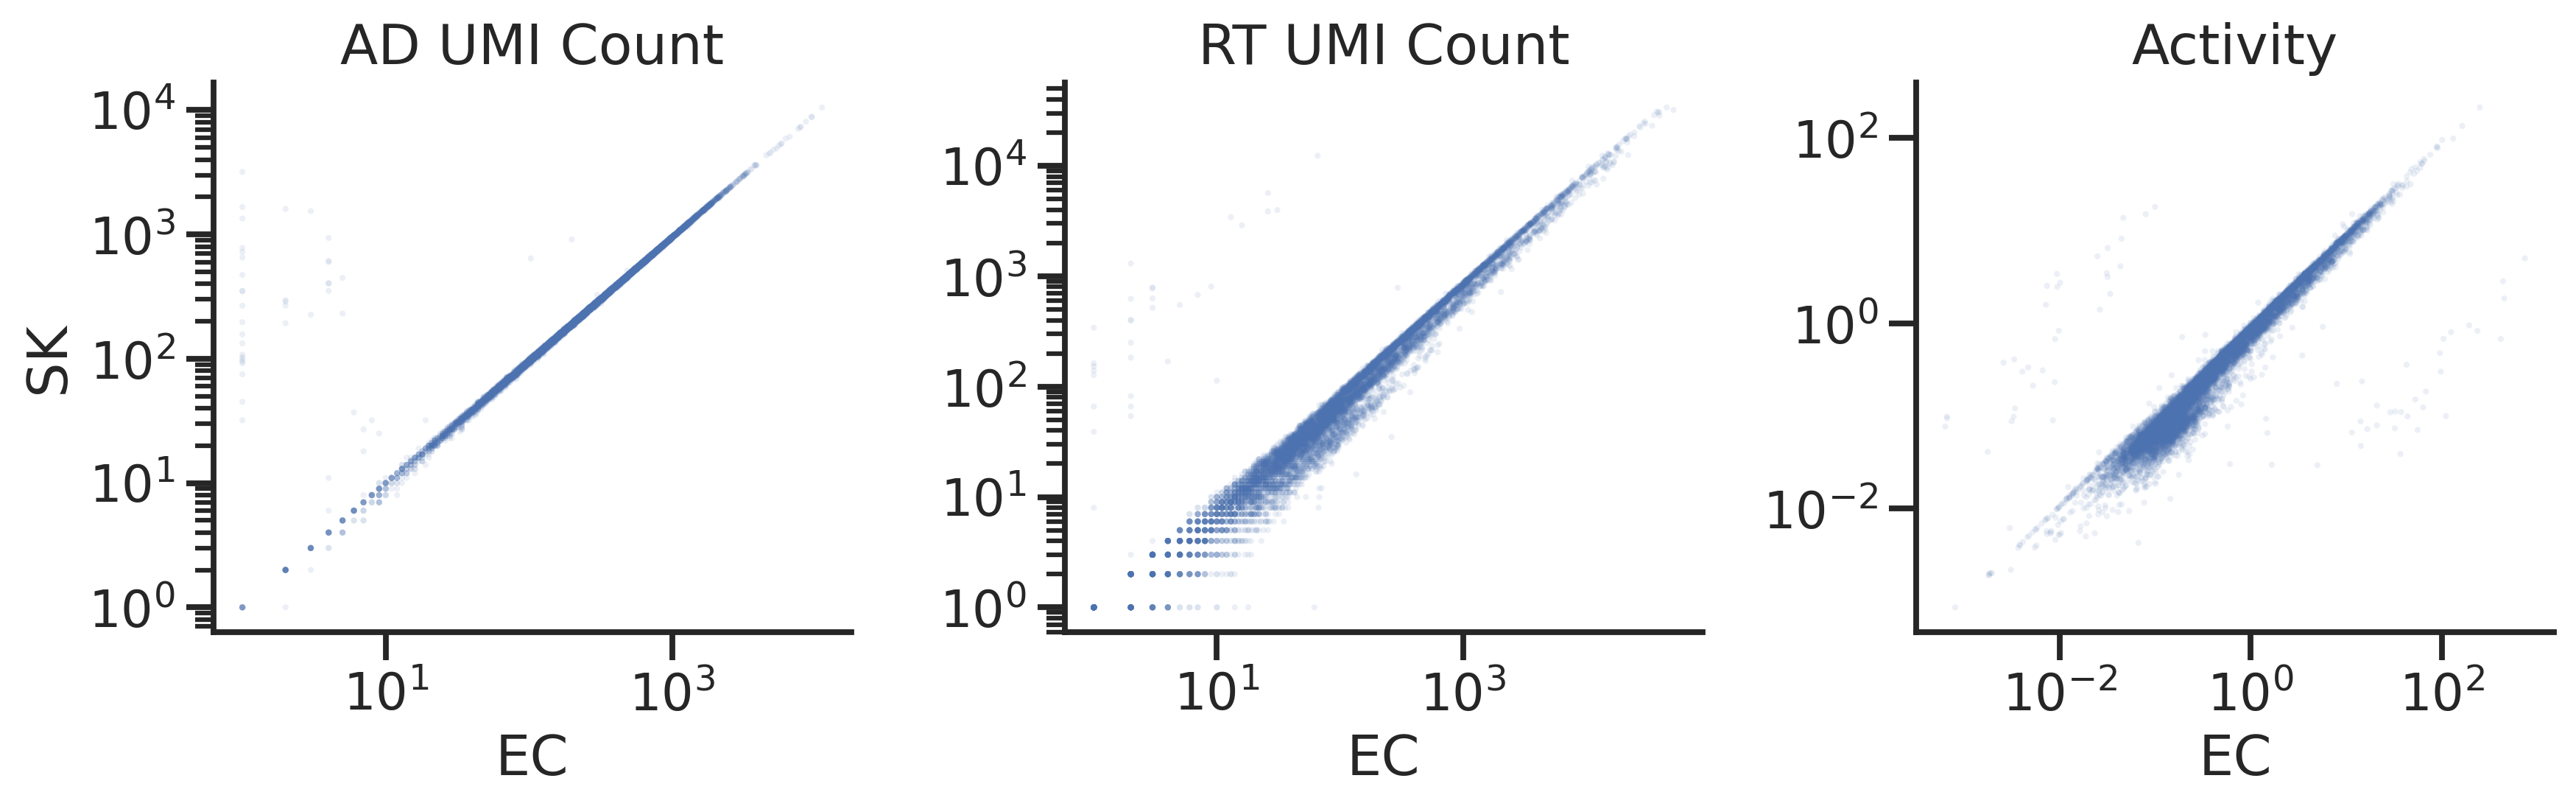

In [24]:
fig, axs = plt.subplots(1,3, figsize = (12,4), dpi = 300)

ax = axs[0]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_AD_umi_count", y = "count_directional_AD", alpha = 0.1, edgecolor = 'none', s = 4, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[0].set_ylabel("SK")
axs[0].set_title("AD UMI Count")
axs[0].set_xlabel("EC")

ax = axs[1]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_RT_umi_count", y = "count_directional_RT", alpha = 0.1, edgecolor = 'none', s = 4, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[1].set_ylabel("")
axs[1].set_title("RT UMI Count")
axs[1].set_xlabel("EC")

ax = axs[2]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_activity", y = "activity_directional", edgecolor = 'none', s = 4, alpha = 0.1, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[2].set_ylabel("")
axs[2].set_title("Activity")
axs[2].set_xlabel("EC")

plt.tight_layout()

sns.despine()

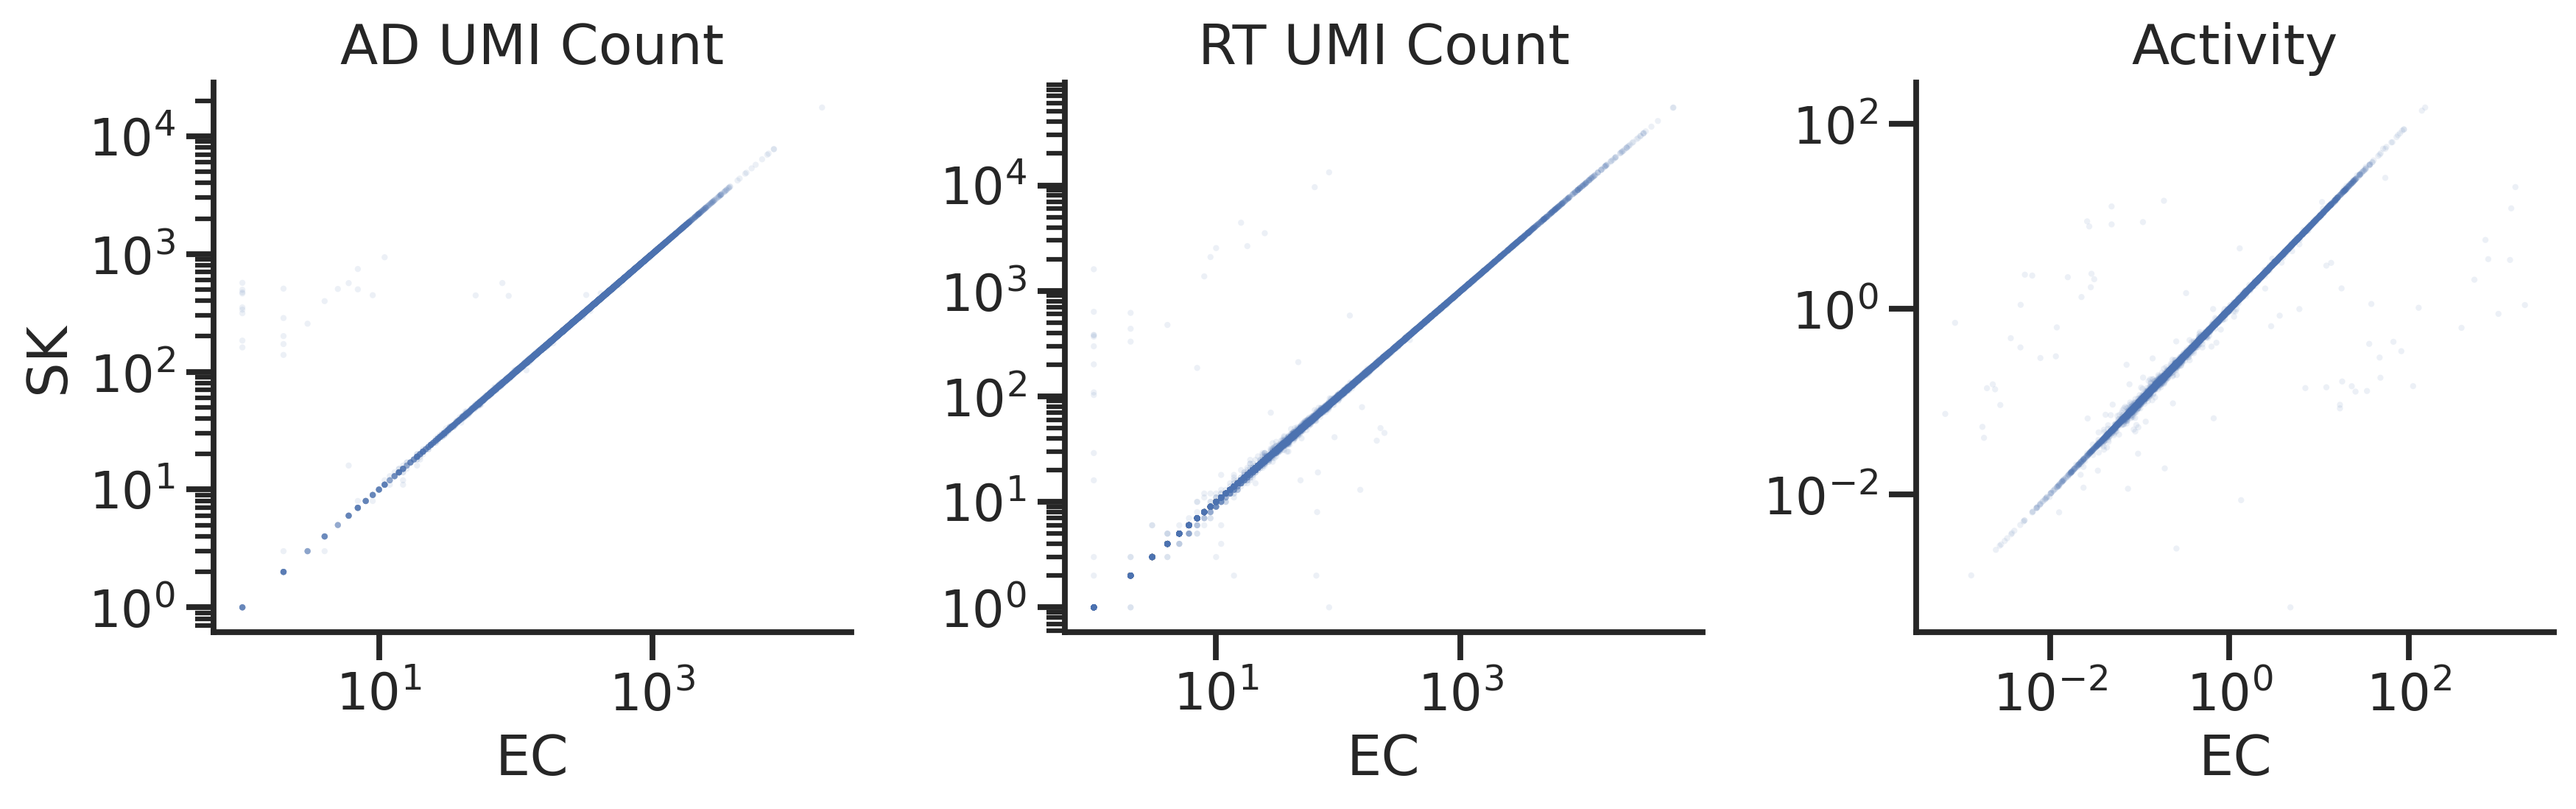

In [25]:
merged_activities = pd.merge(activity_comparison[["AD", "AD_BC", "RPTR_BC", "EC_AD_umi_count", "EC_RT_umi_count", "rep", "time", "EC_activity"]], 
                             AD_RT_merged[["AD", "AD_BC","count_simple_AD", "count_simple_RT", "RPTR_BC", "rep", "time", "activity_simple"]])

fig, axs = plt.subplots(1,3, figsize = (12,4), dpi = 300)

ax = axs[0]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_AD_umi_count", y = "count_simple_AD", alpha = 0.1, edgecolor = 'none', s = 4, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[0].set_ylabel("SK")
axs[0].set_title("AD UMI Count")
axs[0].set_xlabel("EC")

ax = axs[1]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_RT_umi_count", y = "count_simple_RT", alpha = 0.1, edgecolor = 'none', s = 4, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[1].set_ylabel("")
axs[1].set_title("RT UMI Count")
axs[1].set_xlabel("EC")

ax = axs[2]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_activity", y = "activity_simple", edgecolor = 'none', s = 4, alpha = 0.1, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[2].set_ylabel("")
axs[2].set_title("Activity")
axs[2].set_xlabel("EC")

plt.tight_layout()

sns.despine()

# Activity vs error over time

In [39]:
from Bio.Seq import Seq

def translate_dna(seq):
    try:
        return str(Seq(seq).translate(to_stop=False))
    except:
        return None

AD_RT_merged["AD_protein"] = AD_RT_merged["AD"].apply(translate_dna)
AD_RT_merged

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP
...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TCTGGTCATCAAGTTGTTAATTCTTCTTCTTTGAATATTCCAAGAG...,GGATATTACAC,TCTTAAAGGTCAGA,1,30,46,43,23,16,-0.693147,-0.988611,SGHQVVNSSSLNIPRANPNQLYPRQDPRPFTMSPDMLDMQ
342857,ACTAATACTGCTCCAACTACATTTACTTCTGGTTTGTGTTCTTCTT...,GATAAGACTAC,CCCAATCCCCGGCG,1,30,46,46,3,2,-2.730029,-3.135494,TNTAPTTFTSGLCSSYTRRHSHLSASAHGQAGRPHRPPVP
342858,GAAGAAGAAACTAAAGCTGCTGAACCAAATTATGGTTCTGTTGCTA...,ATACGAGAGGT,CACGCTTAGGATAT,1,30,46,43,3,3,-2.730029,-2.662588,EEETKAAEPNYGSVAISLPLERTISSQSMERSGSSSSGSP
342859,TCTTCTTCTTCTTCTCCAAATAACTTTGCTCCAATTGACTTTACTT...,TCTCATATAAT,CTTGTAGTGGCGGC,1,30,46,42,36,25,-0.245122,-0.518794,SSSSSPNNFAPIDFTSFTTDYQPQTWLPSPPHPQPLASNQ


In [40]:
AD_activity_and_error = AD_RT_merged[["AD_protein", "activity_simple", "activity_directional", "rep", "time"]].groupby(["AD_protein", "rep", "time"]).agg([np.mean, np.std, "count"]).reset_index()
AD_activity_and_error.columns = ["AD_protein", "rep", "time", "activity_simple_mean", "activity_simple_std", "count",
                                 "activity_directional_mean", "activity_directional_std", "rep_count"]
AD_activity_and_error = AD_activity_and_error.drop(columns = ["count"])
AD_activity_and_error

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count
0,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,1,0,-3.037696,NaN,-3.832258,NaN,1
1,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,1,5,-2.055344,NaN,-2.613899,NaN,1
2,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,1,10,-2.296854,NaN,-2.717100,NaN,1
3,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,1,15,-2.492454,NaN,-2.720473,NaN,1
4,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,1,30,-2.257393,NaN,-2.529592,NaN,1
...,...,...,...,...,...,...,...,...
229439,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,3,10,-2.305411,NaN,-2.841158,NaN,1
229440,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,3,15,-2.257243,NaN,-2.639057,NaN,1
229441,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,3,30,-2.294689,NaN,-2.476538,NaN,1
229442,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,3,180,-0.901648,NaN,-1.023897,NaN,1


In [41]:
len(AD_activity_and_error["AD_protein"].unique())

11328

In [42]:
AD_activity_and_error_multiple_reps = AD_activity_and_error.dropna()
AD_activity_and_error_multiple_reps

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count
84,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,0,-2.279717,0.557810,-3.664069,0.997556,2
85,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,5,-2.721106,0.703953,-3.110754,0.628751,2
86,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,10,-2.049251,0.645270,-2.421912,0.466157,2
87,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,15,-1.614049,0.925793,-2.025213,0.707836,2
88,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,30,-1.764801,1.104119,-1.882920,0.851337,2
...,...,...,...,...,...,...,...,...
229418,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,10,-1.284666,0.669963,-1.687136,0.659920,2
229419,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,15,-1.824959,0.402364,-2.029691,0.438272,2
229420,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,30,-1.973673,0.683888,-2.272982,0.503543,2
229421,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,180,0.174534,0.143079,0.078488,0.119978,2


In [43]:
len(AD_activity_and_error_multiple_reps["AD_protein"].unique())

4253

In [44]:
AD_activity_and_error_multiple_reps["activity_simple_cv"] = AD_activity_and_error_multiple_reps["activity_simple_std"] / AD_activity_and_error_multiple_reps["activity_simple_mean"]
AD_activity_and_error_multiple_reps["activity_directional_cv"] = AD_activity_and_error_multiple_reps["activity_directional_std"] / AD_activity_and_error_multiple_reps["activity_directional_mean"]
AD_activity_and_error_multiple_reps

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv
84,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,0,-2.279717,0.557810,-3.664069,0.997556,2,-0.244684,-0.272254
85,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,5,-2.721106,0.703953,-3.110754,0.628751,2,-0.258701,-0.202122
86,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,10,-2.049251,0.645270,-2.421912,0.466157,2,-0.314881,-0.192475
87,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,15,-1.614049,0.925793,-2.025213,0.707836,2,-0.573584,-0.349512
88,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,1,30,-1.764801,1.104119,-1.882920,0.851337,2,-0.625634,-0.452137
...,...,...,...,...,...,...,...,...,...,...
229418,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,10,-1.284666,0.669963,-1.687136,0.659920,2,-0.521508,-0.391148
229419,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,15,-1.824959,0.402364,-2.029691,0.438272,2,-0.220478,-0.215931
229420,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,30,-1.973673,0.683888,-2.272982,0.503543,2,-0.346505,-0.221534
229421,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,3,180,0.174534,0.143079,0.078488,0.119978,2,0.819780,1.528615


82301
82301


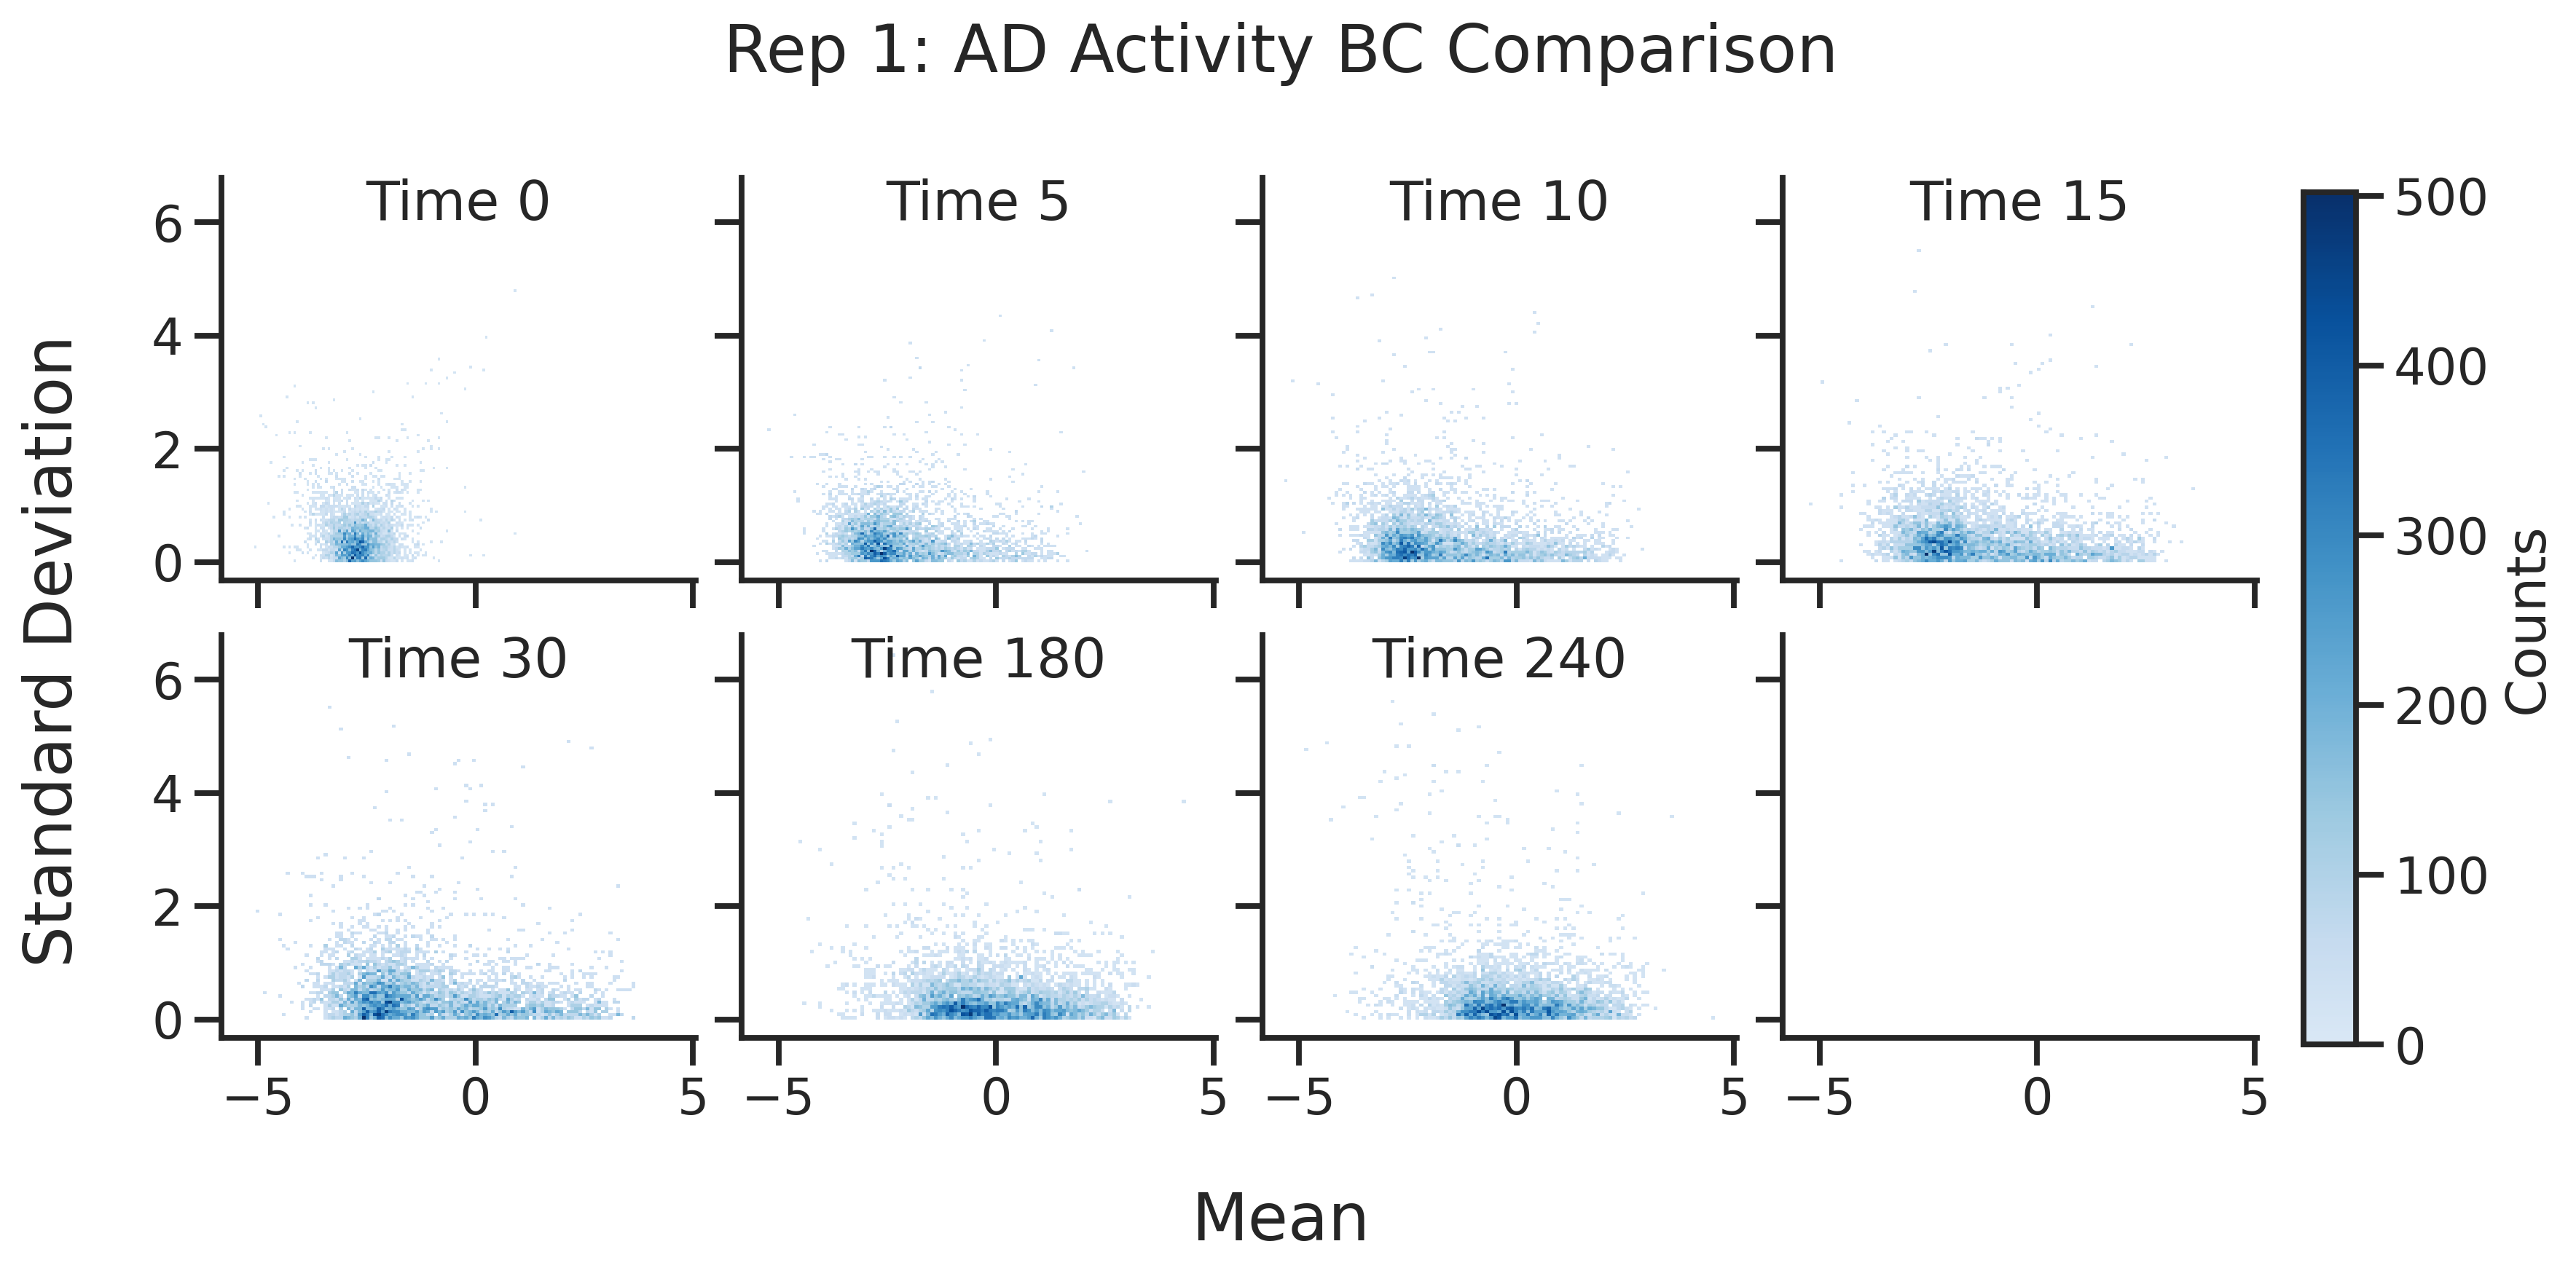

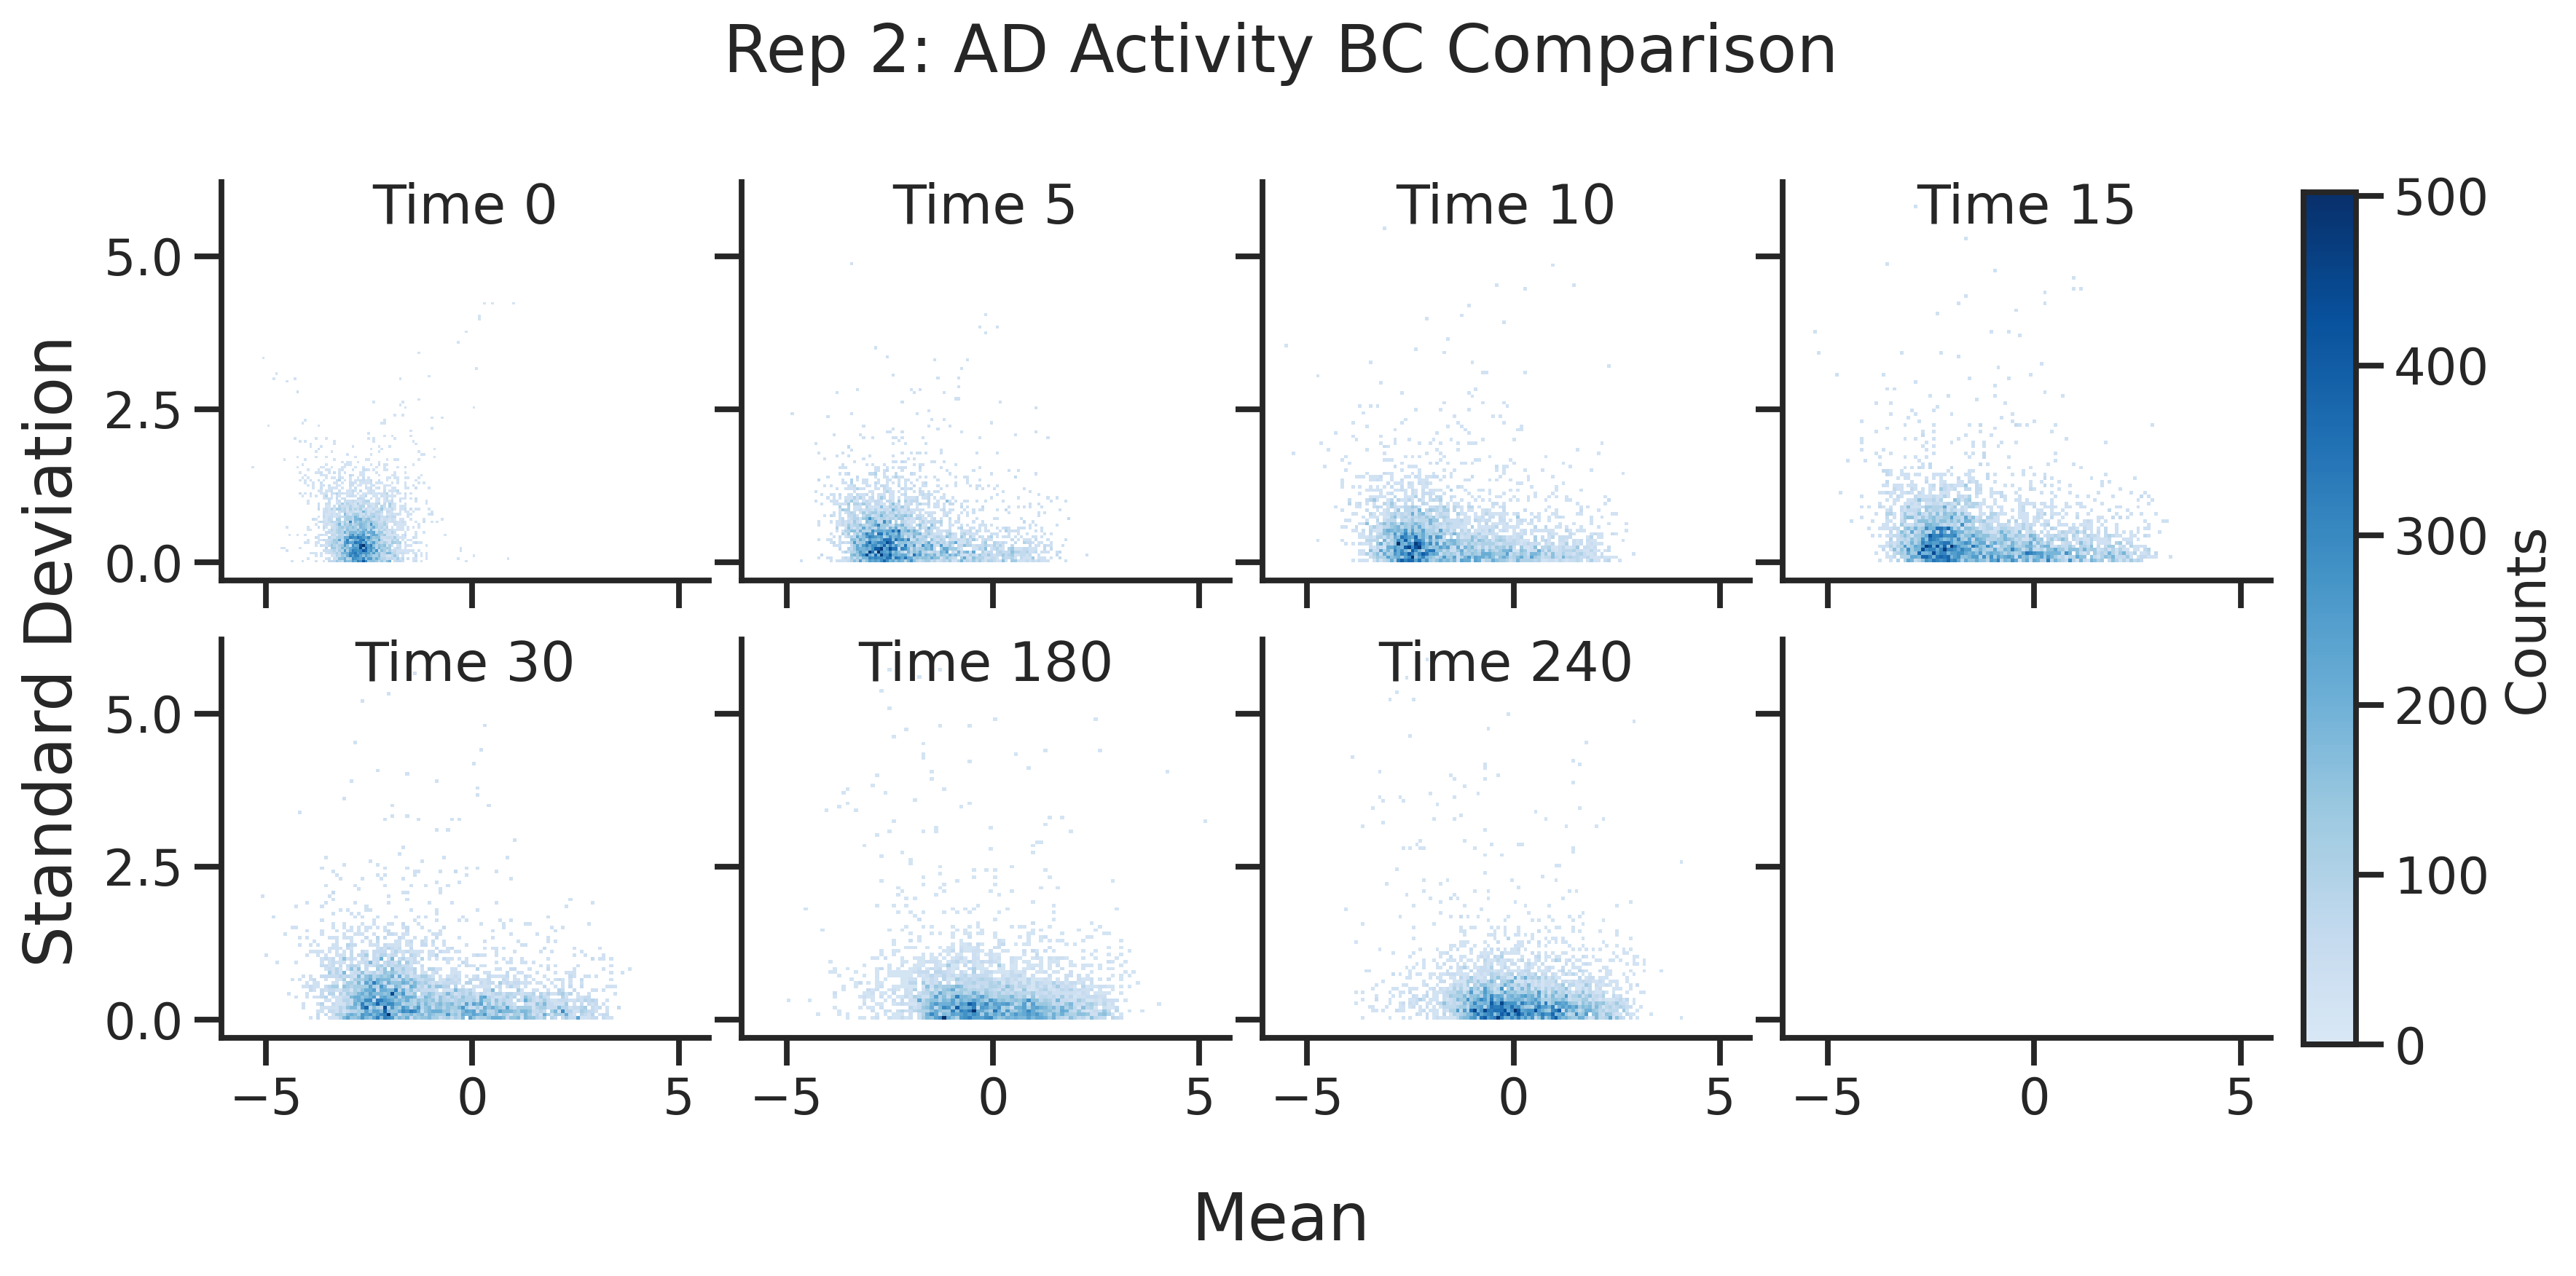

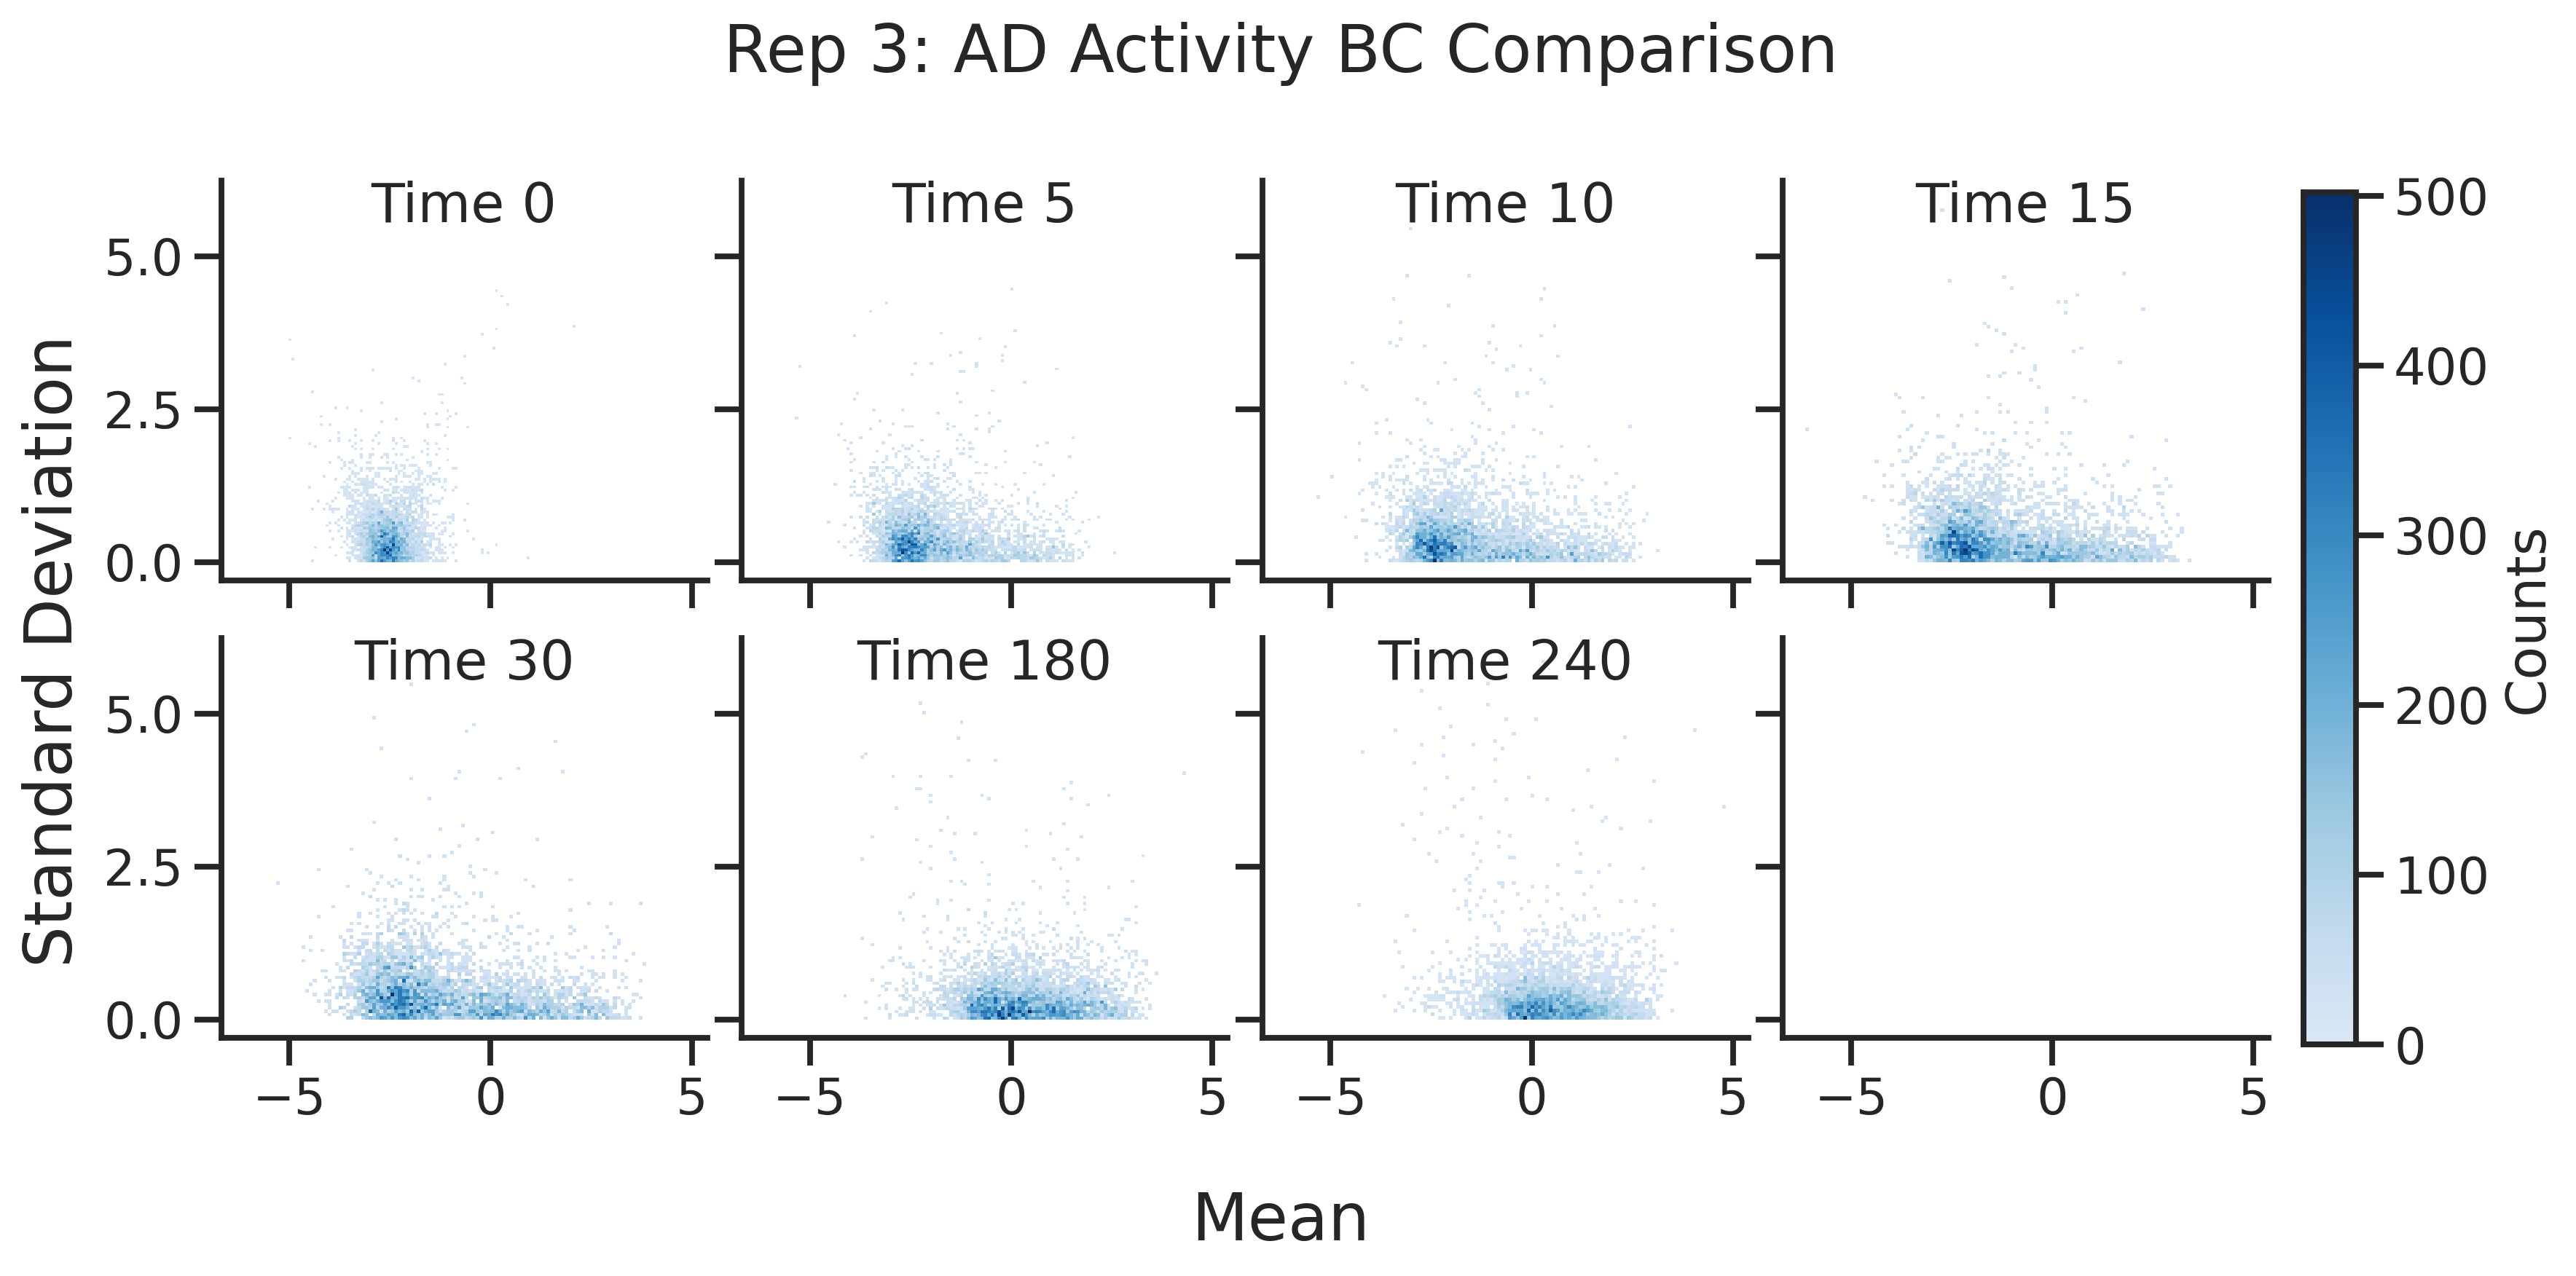

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

sns.set_context("talk")
sns.set_style('ticks')

# Filter and log-transform
df = AD_activity_and_error_multiple_reps.copy()
print(len(df))
# df = df[(df["activity_directional_mean"] > 0) & (df["activity_directional_std"] > 0)]
print(len(df))

# df["log_mean"] = np.log10(df["activity_directional_mean"])
# df["log_std"] = np.log10(df["activity_directional_std"])

# Truncate colormap
def truncate_colormap(cmap, minval=0.25, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Blues, 0.15, 1.0)

# Compute global max count for all plots
counts, _, _ = np.histogram2d(df["activity_directional_mean"], df["activity_directional_std"], bins=80)
global_max = counts.max()

# Get unique reps
reps = df["rep"].unique()

for rep in reps:
    df_rep = df[df["rep"] == rep]
    times = sorted(df_rep["time"].unique())

    xmin_all = df_rep["activity_directional_mean"].min()
    xmax_all = df_rep["activity_directional_mean"].max()
    ymin_all = df_rep["activity_directional_std"].min()
    ymax_all = df_rep["activity_directional_std"].max()

    xpad = 0.1
    ypad = 0.1
    
    xmin_all -= xpad
    xmax_all += xpad
    ymin_all -= ypad
    ymax_all += ypad
    
    ncols = len(times) // 2 + 1
    fig, axes = plt.subplots(2, ncols, figsize=(3*ncols, 6), sharex=True, sharey=True, dpi = 300)
    
    if ncols == 1:
        axes = [axes]  # make iterable
    else:
        axes = axes.flatten()

    for ax, time in zip(axes, times):
        data = df_rep[df_rep["time"] == time]
        sns.histplot(
            data=data,
            x="activity_directional_mean",
            y="activity_directional_std",
            bins=100,
            cmap=cmap,
            cbar=False
        , ax=ax)
        
        ax.set_title(f"Time {time}", y = 0.85)
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    fig.suptitle(f"Rep {rep}: AD Activity BC Comparison")
    fig.supxlabel("Mean", ha='center', y = 0.04)
    fig.supylabel("Standard Deviation", va='center', rotation='vertical')
    
    # Add shared vertical colorbar on the right
    sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=global_max), cmap=cmap)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.89, 0.2, 0.02, 0.65])  # [left, bottom, width, height]
    fig.colorbar(sm, cax=cbar_ax, label="Counts")
    
    
    plt.tight_layout(rect=[0, 0, 0.9, 1], h_pad=0.5, w_pad=0.1)  # leave space for colorbar
    sns.despine()
    plt.show()

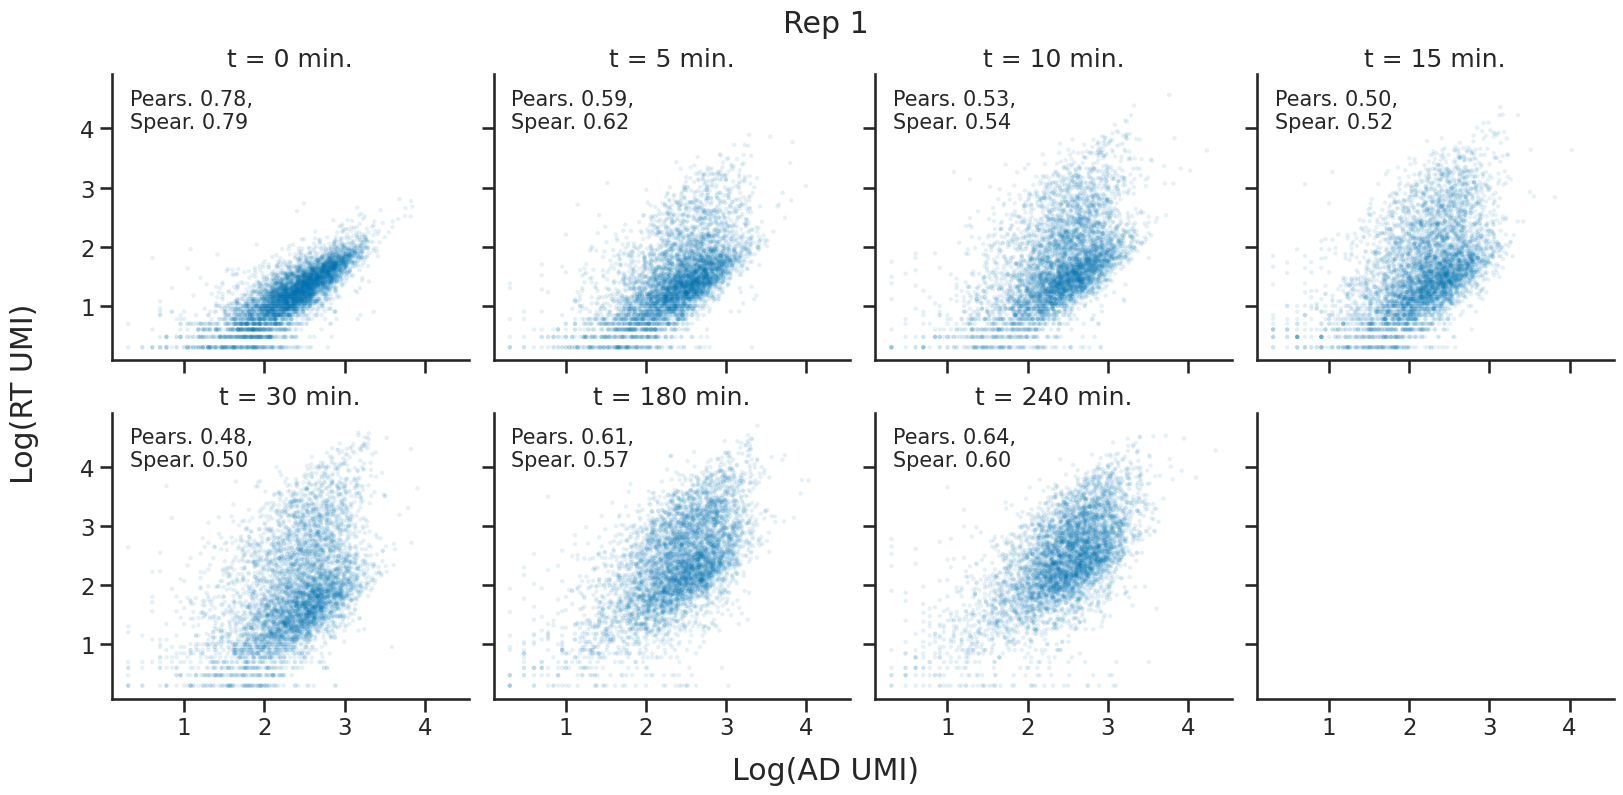

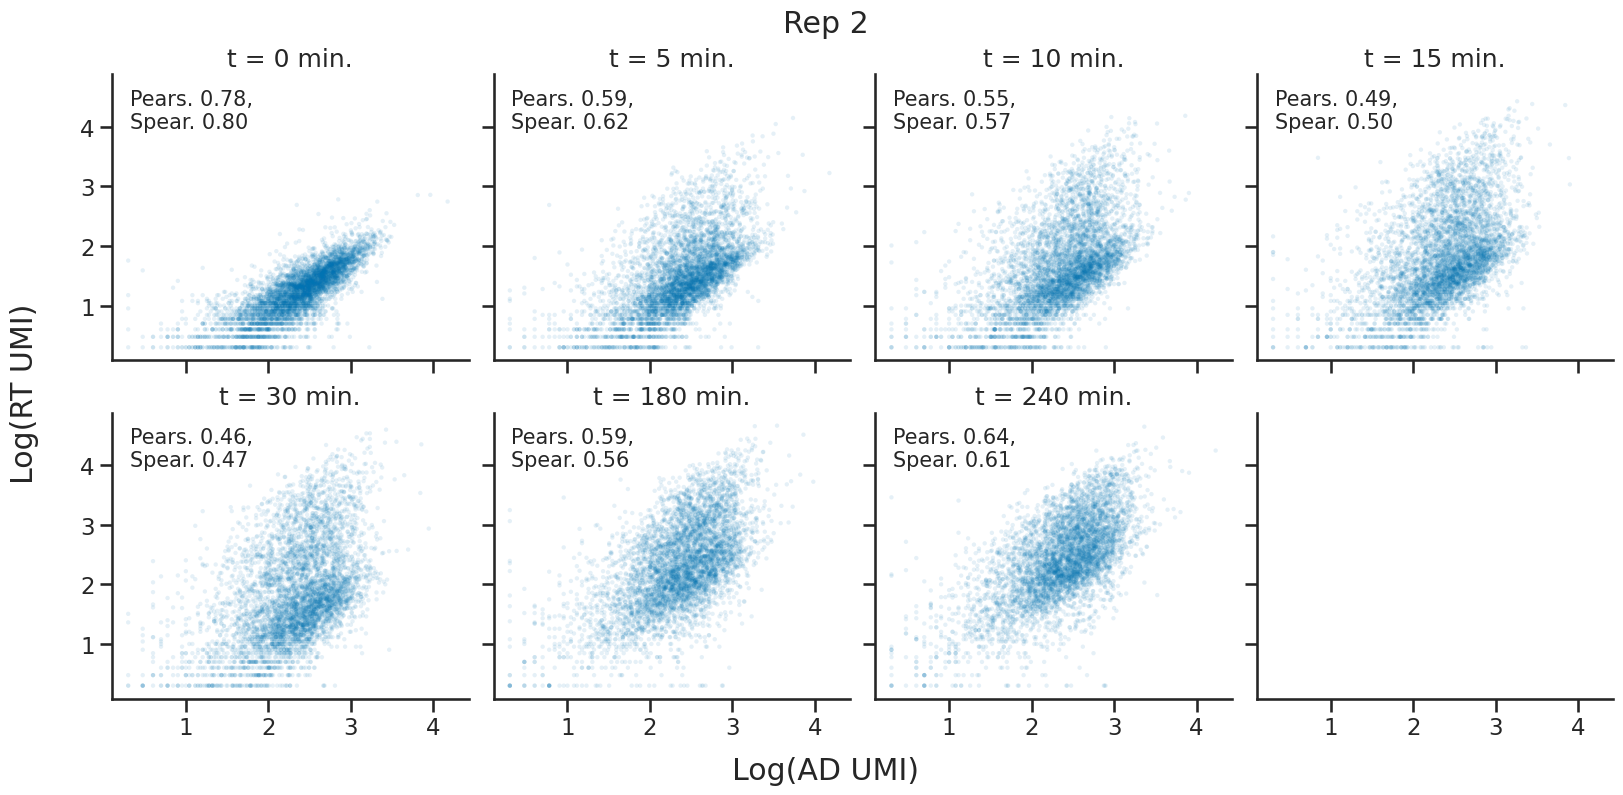

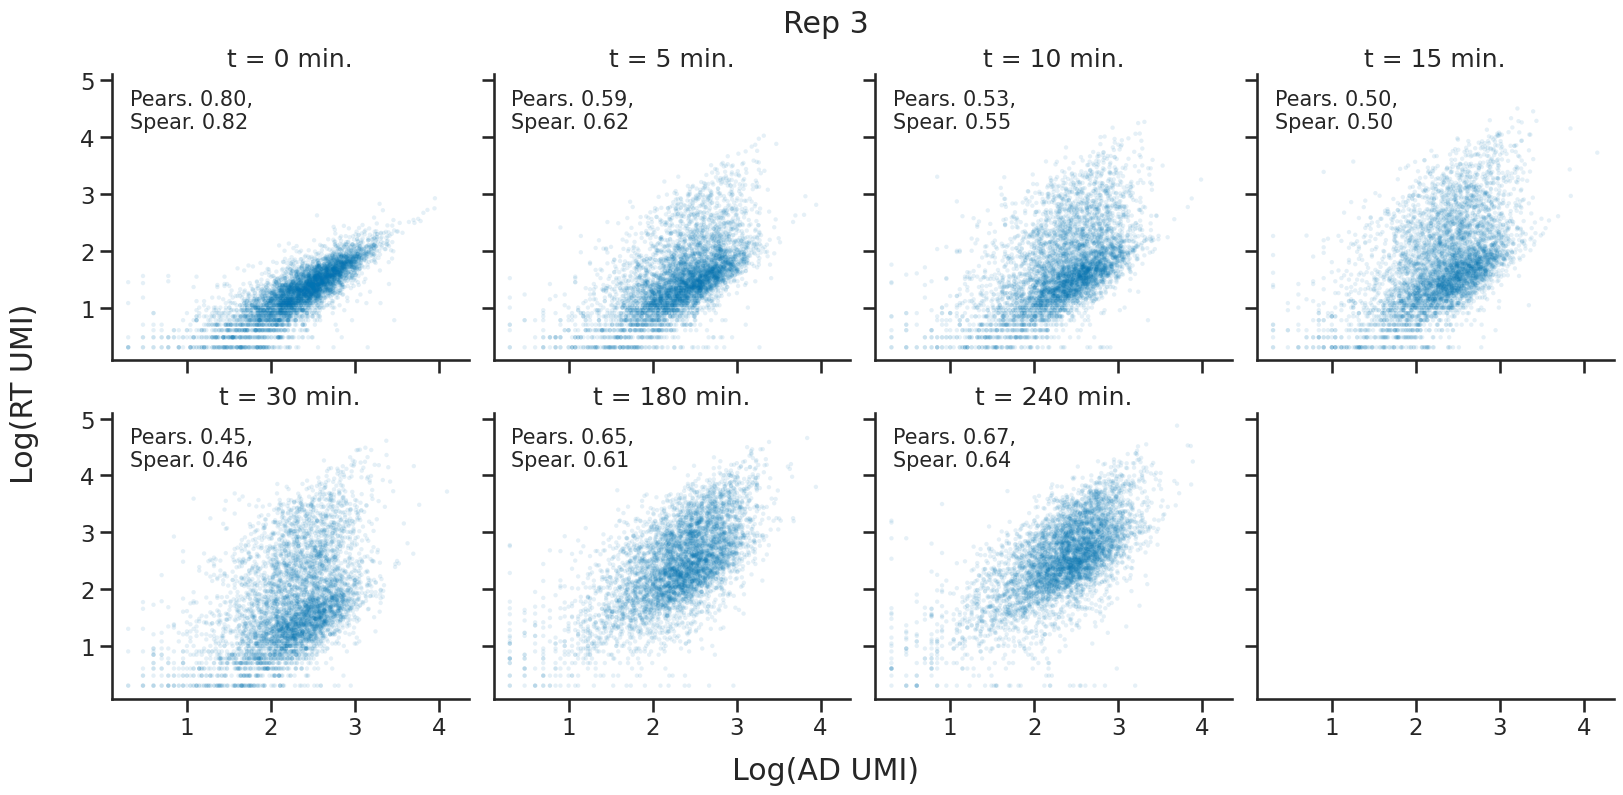

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import matplotlib.gridspec as gridspec

for rep in [1,2,3]:
    # Sort time points
    time_points = sorted(AD_RT_merged["time"].unique())
    fig,axs = plt.subplots(2,4, figsize = (16,8), sharex = True, sharey = True)
    axs = axs.flatten()
    
    
    for time, ax in zip(time_points, axs):
        # Add a tiny offset to avoid log(0)
        df_sample = AD_RT_merged.copy()
        df_sample = df_sample[df_sample["rep"] == rep]
        df_sample = df_sample[df_sample["time"] == time]
        df_sample["count_directional_AD_plot"] = np.log10(df_sample["count_directional_AD"] + 1)
        df_sample["count_directional_RT_plot"] = np.log10(df_sample["count_directional_RT"] + 1)
        
        # Sample for plotting
        df_plot = df_sample.sample(5000)
        
        # Compute correlations
        pearson_corr, pearson_p = pearsonr(df_plot["count_directional_AD_plot"], df_plot["count_directional_RT_plot"])
        spearman_corr, spearman_p = spearmanr(df_plot["count_directional_AD_plot"], df_plot["count_directional_RT_plot"])
        
        # Jointplot with scatter + marginal histograms
        sns.scatterplot(
            data=df_plot,
            x="count_directional_AD_plot",
            y="count_directional_RT_plot",
            alpha=0.1,
            edgecolor='none',
            s=10, ax = ax, color = sns.color_palette('colorblind')[0]
        )
        
        # Annotate correlations on the plot
        textstr = f"Pears. {pearson_corr:.2f},\nSpear. {spearman_corr:.2f}"
        #textstr = f"Pears. {pearson_corr:.2f}"
        
        ax.text(
            0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize='small',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0)
        )
        ax.set_title(f"t = {time} min.")
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Axis labels
        #g.set_axis_labels("Log(AD UMIs)", "Log(RT UMIs)", fontsize='medium')
    
    fig.supxlabel("Log(AD UMI)")
    fig.supylabel("Log(RT UMI)", x= -0.01)
    fig.suptitle(f"Rep {rep}")
    sns.despine()
    plt.tight_layout(pad = 0.5)
    plt.show()
    # plt.savefig("../../

In [87]:
AD_RT_merged

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP
...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TCTGGTCATCAAGTTGTTAATTCTTCTTCTTTGAATATTCCAAGAG...,GGATATTACAC,TCTTAAAGGTCAGA,1,30,46,43,23,16,-0.693147,-0.988611,SGHQVVNSSSLNIPRANPNQLYPRQDPRPFTMSPDMLDMQ
342857,ACTAATACTGCTCCAACTACATTTACTTCTGGTTTGTGTTCTTCTT...,GATAAGACTAC,CCCAATCCCCGGCG,1,30,46,46,3,2,-2.730029,-3.135494,TNTAPTTFTSGLCSSYTRRHSHLSASAHGQAGRPHRPPVP
342858,GAAGAAGAAACTAAAGCTGCTGAACCAAATTATGGTTCTGTTGCTA...,ATACGAGAGGT,CACGCTTAGGATAT,1,30,46,43,3,3,-2.730029,-2.662588,EEETKAAEPNYGSVAISLPLERTISSQSMERSGSSSSGSP
342859,TCTTCTTCTTCTTCTCCAAATAACTTTGCTCCAATTGACTTTACTT...,TCTCATATAAT,CTTGTAGTGGCGGC,1,30,46,42,36,25,-0.245122,-0.518794,SSSSSPNNFAPIDFTSFTTDYQPQTWLPSPPHPQPLASNQ


<Axes: xlabel='count_directional_AD', ylabel='Density'>

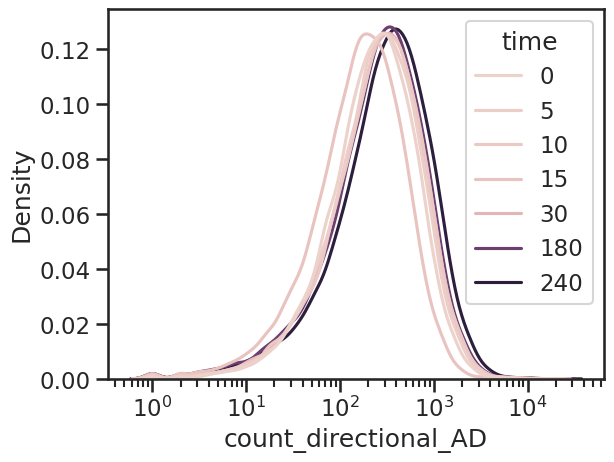

In [98]:
sns.kdeplot(data = AD_RT_merged[AD_RT_merged["rep"] == 1], x= "count_directional_AD", hue = "time", log_scale = (True,False))

<Axes: xlabel='count_directional_RT', ylabel='Density'>

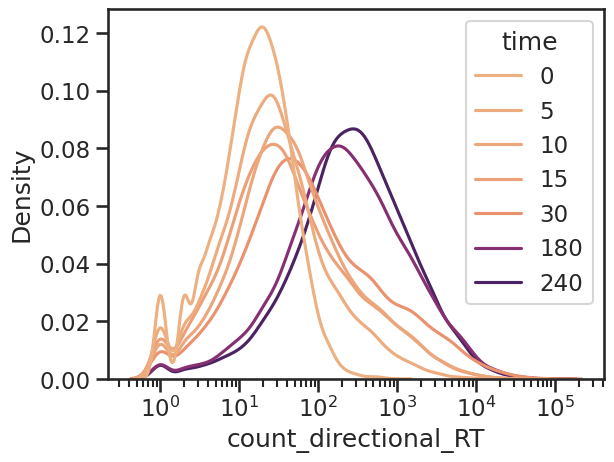

In [99]:
sns.kdeplot(data = AD_RT_merged[AD_RT_merged["rep"] == 1], x= "count_directional_RT", hue = "time", log_scale = (True,False), palette = 'flare')